# Biomass EDA for LTN Rule Discovery

This notebook performs exploratory data analysis on pasture biomass prediction data to discover logical rules suitable for encoding as soft constraints in a Logical Tensor Network (LTN) framework.

## Table of Contents

1. [Setup and Configuration](#1-setup-and-configuration)
2. [Data Loading and Validation](#2-data-loading-and-validation)
3. [Mathematical Rule Discovery](#3-mathematical-rule-discovery)
4. [Species-Specific Pattern Analysis](#4-species-specific-pattern-analysis)
5. [Temporal Pattern Discovery](#5-temporal-pattern-discovery)
6. [Geographic Pattern Analysis](#6-geographic-pattern-analysis)
7. [NDVI-Biomass Relationship Analysis](#7-ndvi-biomass-relationship-analysis)
8. [Height-Biomass Relationship Analysis](#8-height-biomass-relationship-analysis)
9. [Image Data Characterization](#9-image-data-characterization)
10. [Shared Feature Representation Opportunities](#10-shared-feature-representation-opportunities)
11. [Baseline Comparison Insights](#11-baseline-comparison-insights)
12. [Data Distribution and Outlier Analysis](#12-data-distribution-and-outlier-analysis)
13. [Missing Data Analysis](#13-missing-data-analysis)
14. [Feature Correlation Analysis](#14-feature-correlation-analysis)
15. [Comprehensive Rule Summary Report](#15-comprehensive-rule-summary-report)
16. [Export and Persistence of Analysis Results](#16-export-and-persistence-of-analysis-results)

## 1. Setup and Configuration

This section sets up the notebook environment with all required libraries and configuration for Google Colab compatibility.

In [3]:
# Core data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway

# Machine learning utilities
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Image processing
from PIL import Image
import cv2

# File and path management
import json
from pathlib import Path
import os

# Date/time handling
from datetime import datetime

# Warnings control
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("[OK] All libraries imported successfully")

✓ All libraries imported successfully


### File Path Configuration

Configure paths for data files with Google Colab compatibility. Update these paths based on your environment:
- For local execution: Use relative or absolute paths
- For Google Colab: Mount Google Drive and update paths accordingly

In [4]:
# Detect environment
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Configure paths based on environment
if IN_COLAB:
    # Mount Google Drive for Colab
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Update these paths to your Google Drive location
    BASE_DIR = Path('/content/drive/MyDrive/biomass_data')
    CSV_PATH = BASE_DIR / 'train.csv'
    IMAGE_DIR = BASE_DIR / 'train'
else:
    # Local paths
    BASE_DIR = Path('.')
    CSV_PATH = BASE_DIR / 'train.csv'
    IMAGE_DIR = BASE_DIR / 'train'

print(f"Base directory: {BASE_DIR}")
print(f"CSV path: {CSV_PATH}")
print(f"Image directory: {IMAGE_DIR}")

# Verify paths exist
if CSV_PATH.exists():
    print("[OK] CSV file found")
else:
    print("[WARNING] CSV file not found. Please update CSV_PATH.")

if IMAGE_DIR.exists():
    print("[OK] Image directory found")
else:
    print("[WARNING] Image directory not found. Please update IMAGE_DIR.")

Running in local environment
Base directory: .
CSV path: train.csv
Image directory: train
✓ CSV file found
✓ Image directory found


### Output Directory Setup

Create organized directory structure for exporting analysis results.

In [5]:
def setup_output_directories(base_output_dir='eda_results'):
    """
    Create organized output directory structure for analysis results.
    
    Parameters:
    -----------
    base_output_dir : str
        Base directory name for all outputs (default: 'eda_results')
    
    Returns:
    --------
    dict
        Dictionary mapping output type to directory path
    """
    base_path = Path(base_output_dir)
    
    # Define directory structure
    directories = {
        'base': base_path,
        'rules': base_path / 'rules',
        'visualizations': base_path / 'visualizations',
        'visualizations_correlations': base_path / 'visualizations' / 'correlations',
        'visualizations_distributions': base_path / 'visualizations' / 'distributions',
        'visualizations_regressions': base_path / 'visualizations' / 'regressions',
        'visualizations_temporal': base_path / 'visualizations' / 'temporal',
        'statistics': base_path / 'statistics'
    }
    
    # Create all directories
    for dir_type, dir_path in directories.items():
        dir_path.mkdir(parents=True, exist_ok=True)
    
    print("[OK] Output directory structure created:")
    print(f"  - Base: {directories['base']}")
    print(f"  - Rules: {directories['rules']}")
    print(f"  - Visualizations: {directories['visualizations']}")
    print(f"    - Correlations: {directories['visualizations_correlations']}")
    print(f"    - Distributions: {directories['visualizations_distributions']}")
    print(f"    - Regressions: {directories['visualizations_regressions']}")
    print(f"    - Temporal: {directories['visualizations_temporal']}")
    print(f"  - Statistics: {directories['statistics']}")
    
    return directories

# Create output directories
output_dirs = setup_output_directories()

# Store for later use
OUTPUT_BASE = output_dirs['base']
OUTPUT_RULES = output_dirs['rules']
OUTPUT_VIZ = output_dirs['visualizations']
OUTPUT_STATS = output_dirs['statistics']

✓ Output directory structure created:
  - Base: eda_results
  - Rules: eda_results\rules
  - Visualizations: eda_results\visualizations
    - Correlations: eda_results\visualizations\correlations
    - Distributions: eda_results\visualizations\distributions
    - Regressions: eda_results\visualizations\regressions
    - Temporal: eda_results\visualizations\temporal
  - Statistics: eda_results\statistics


### PyTorch Compatibility Notes

This notebook uses PyTorch-compatible data structures for future model development:
- NumPy arrays can be easily converted to PyTorch tensors using `torch.from_numpy()`
- Pandas DataFrames can be converted via `.values` then to tensors
- Image arrays loaded with PIL/OpenCV are compatible with `torchvision.transforms`
- Data organization (357 images x 5 targets) aligns with multi-task learning setup

---
## 2. Data Loading and Validation

Load the biomass dataset and validate its structure to ensure data integrity before analysis.

In [6]:
# Import validation module
from data_validation import (
    validate_csv_structure,
    validate_image_references,
    check_data_structure_consistency
)

print("="*80)
print("DATA LOADING AND VALIDATION")
print("="*80)

# Load CSV data
try:
    df = pd.read_csv(CSV_PATH)
    print(f"\n[OK] CSV loaded successfully: {len(df)} rows, {len(df.columns)} columns")
    print(f"\nColumns: {list(df.columns)}")
except FileNotFoundError:
    print(f"\n[WARNING] ERROR: CSV file not found at {CSV_PATH}")
    print("Please update the CSV_PATH variable in the configuration section above.")
    raise

# Validate CSV structure
csv_validation = validate_csv_structure(df)
print(f"\n{'='*80}")
print("CSV STRUCTURE VALIDATION")
print(f"{'='*80}")
for check, result in csv_validation.items():
    status = "[OK]" if result else "[FAIL]"
    print(f"{status} {check}: {result}")

# Validate image references
if IMAGE_DIR.exists():
    image_validation = validate_image_references(df, str(IMAGE_DIR))
    print(f"\n{'='*80}")
    print("IMAGE REFERENCE VALIDATION")
    print(f"{'='*80}")
    print(f"[OK] Total images referenced: {image_validation['total_images']}")
    found_count = image_validation['total_images'] - image_validation['missing_count']
    print(f"[OK] Images found: {found_count}")
    print(f"[OK] Images missing: {image_validation['missing_count']}")
    if image_validation['missing_count'] > 0:
        print(f"\n[WARNING] Missing images (first 5): {image_validation['missing_images'][:5]}")
else:
    print(f"\n[WARNING] WARNING: Image directory not found at {IMAGE_DIR}")
    print("Image validation skipped. Update IMAGE_DIR if needed.")

# Check data structure consistency
consistency_check = check_data_structure_consistency(df)
print(f"\n{'='*80}")
print("DATA STRUCTURE CONSISTENCY")
print(f"{'='*80}")
print(f"[OK] Total images checked: {consistency_check['total_images']}")
print(f"[OK] All images have correct structure: {consistency_check['structure_valid']}")
if not consistency_check['structure_valid']:
    print(f"\n[WARNING] Inconsistent images (first 5): {[img['image_path'] for img in consistency_check['images_with_wrong_count'][:5]]}")

print(f"\n{'='*80}")
print("VALIDATION SUMMARY")
print(f"{'='*80}")
all_valid = all(csv_validation.values()) and consistency_check['structure_valid']
if all_valid:
    print("[OK] All validation checks passed! Dataset is ready for analysis.")
else:
    print("[WARNING] Some validation checks failed. Proceeding with caution...")

DATA LOADING AND VALIDATION

✓ CSV loaded successfully: 1785 rows, 9 columns

Columns: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target']

CSV STRUCTURE VALIDATION
✓ row_count: True
✓ row_count_actual: 1785
✓ columns: True
✗ missing_columns: []
✓ unique_images: True
✓ unique_images_actual: 357
✓ target_types: True
✓ target_types_actual: 5
✓ target_types_found: ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
✓ all_valid: True
✗ errors: []

IMAGE REFERENCE VALIDATION
✓ Total images referenced: 357
✓ Images found: 357
✓ Images missing: 0



DATA STRUCTURE CONSISTENCY
✓ Total images checked: 357
✓ All images have correct structure: True

VALIDATION SUMMARY
⚠ Some validation checks failed. Proceeding with caution...


### Convert to Wide Format

Convert the dataset from long format (5 rows per image, one per target metric) to wide format (1 row per image with all target metrics as columns).

In [7]:
def pivot_to_wide_format(df_long: pd.DataFrame) -> pd.DataFrame:
    """Convert long format data to wide format (one row per image)."""
    df_wide = df_long.pivot_table(
        index=['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm'],
        columns='target_name',
        values='target',
        aggfunc='first'
    ).reset_index()
    
    return df_wide

# Convert to wide format
df_wide = pivot_to_wide_format(df)
print(f"[OK] Converted to wide format: {len(df_wide)} samples (one per image)")
print(f"\nColumns: {list(df_wide.columns)}")
print(f"\nFirst few rows:")
display(df_wide.head())

# Store target column names for later use
TARGET_COLS = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
AVAILABLE_TARGETS = [c for c in TARGET_COLS if c in df_wide.columns]
print(f"\n[OK] Target metrics available: {AVAILABLE_TARGETS}")

✓ Converted to wide format: 357 samples (one per image)

Columns: ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']

First few rows:


target_name,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605



✓ Target metrics available: ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']


---
## 3. Mathematical Rule Discovery

Discover mathematical relationships between target metrics that can be encoded as soft constraints in LTN.

In [8]:
# Import mathematical rule discovery module
from mathematical_rule_discovery import (
    test_additive_constraint,
    compute_target_correlations,
    discover_linear_relationships,
    analyze_gdm_relationships
)
from visualization_utils import plot_correlation_heatmap, plot_scatter_with_regression

print("="*80)
print("MATHEMATICAL RULE DISCOVERY")
print("="*80)

# Initialize list to collect all discovered rules
all_rules = []

MATHEMATICAL RULE DISCOVERY


### 3.1 Additive Constraint: Dry Total = Clover + Dead + Green


ADDITIVE CONSTRAINT ANALYSIS
Rule: Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g
Mean residual: 0.0009g
Std residual: 0.0163g
Max residual: 0.3088g
Violation rate (>1g): 0.00%


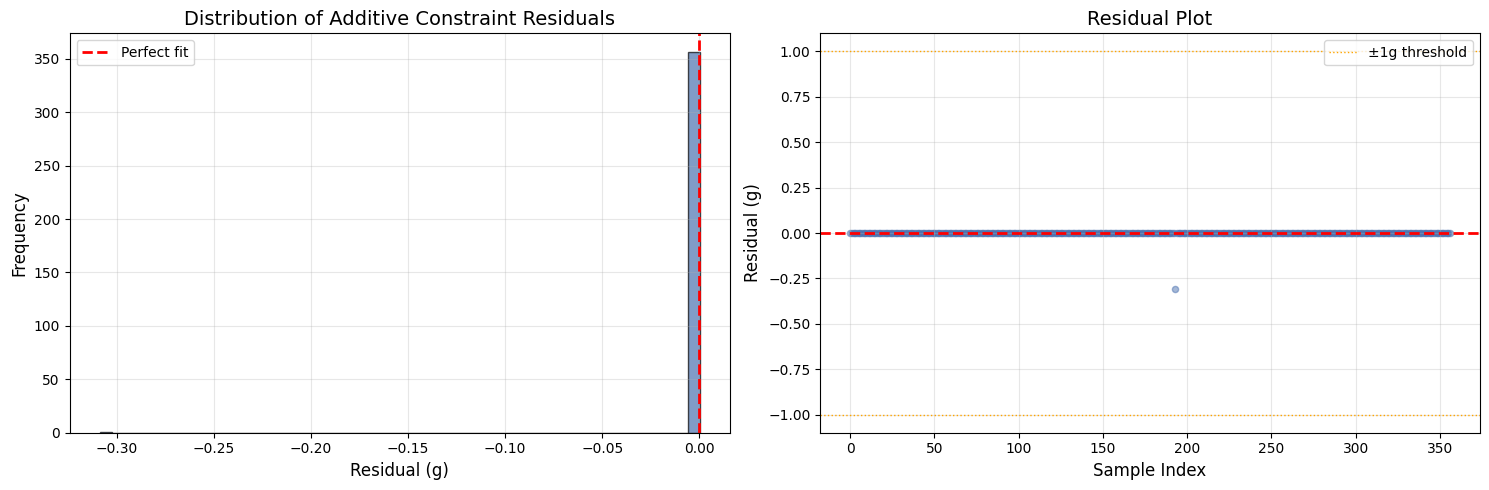


✓ Saved residual plots to eda_results\visualizations\additive_constraint_residuals.png


In [9]:
# Test additive constraint
additive_result = test_additive_constraint(df_wide)

print("\nADDITIVE CONSTRAINT ANALYSIS")
print("Rule: Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g")
print("="*80)
print(f"Mean residual: {additive_result['mean_residual']:.4f}g")
print(f"Std residual: {additive_result['std_residual']:.4f}g")
print(f"Max residual: {additive_result['max_residual']:.4f}g")
print(f"Violation rate (>1g): {additive_result['violation_rate']:.2%}")

# Add rule to collection
all_rules.append(additive_result['rule_candidate'])

# Visualize residuals
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(additive_result['residual_distribution'], bins=50, edgecolor='black', alpha=0.7)
ax[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect fit')
ax[0].set_xlabel('Residual (g)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Additive Constraint Residuals')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].scatter(range(len(additive_result['residual_distribution'])), additive_result['residual_distribution'], 
              alpha=0.5, s=20)
ax[1].axhline(0, color='red', linestyle='--', linewidth=2)
ax[1].axhline(1, color='orange', linestyle=':', linewidth=1, label='±1g threshold')
ax[1].axhline(-1, color='orange', linestyle=':', linewidth=1)
ax[1].set_xlabel('Sample Index')
ax[1].set_ylabel('Residual (g)')
ax[1].set_title('Residual Plot')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_VIZ / 'additive_constraint_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[OK] Saved residual plots to {OUTPUT_VIZ / 'additive_constraint_residuals.png'}")

### 3.2 Target Metric Correlations


TARGET METRICS CORRELATION MATRIX


target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
target_name,,,,,
Dry_Clover_g,1.000000,-0.175548,-0.276582,0.104185,0.204213
Dry_Dead_g,-0.175548,1.000000,0.095554,0.453912,0.012028
Dry_Green_g,-0.276582,0.095554,1.000000,0.830315,0.884257
Dry_Total_g,0.104185,0.453912,0.830315,1.000000,0.896441
GDM_g,0.204213,0.012028,0.884257,0.896441,1.000000


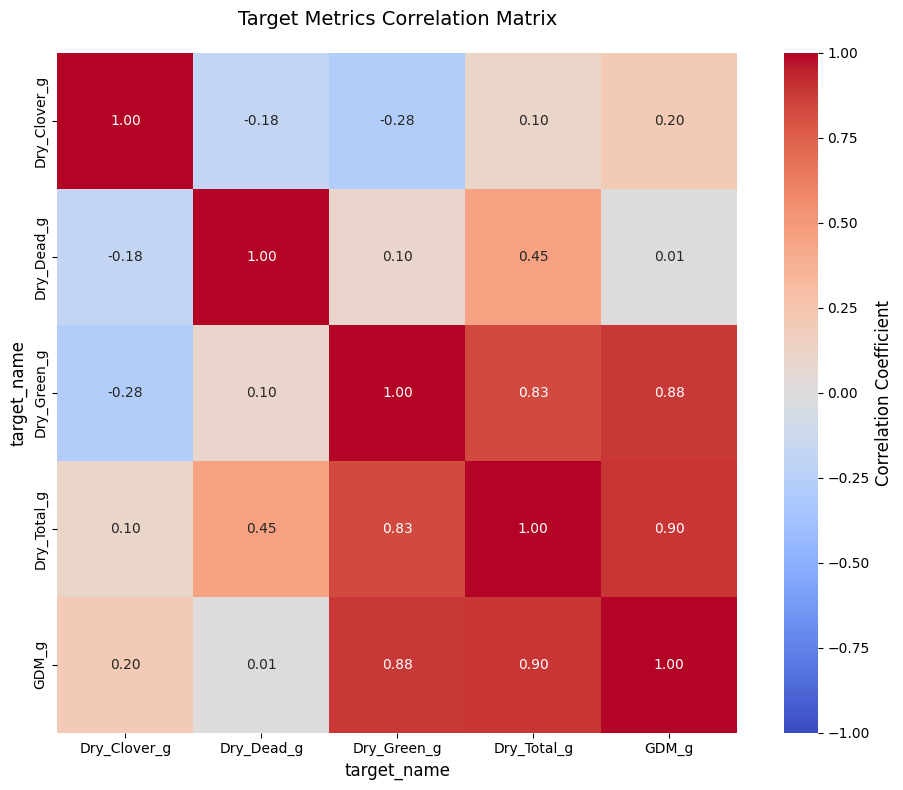


✓ Saved correlation heatmap to eda_results\visualizations\target_correlations.png


In [10]:
# Compute target correlations
target_corr = compute_target_correlations(df_wide)

print("\nTARGET METRICS CORRELATION MATRIX")
print("="*80)
display(target_corr)

# Visualize correlation heatmap
fig_corr = plot_correlation_heatmap(target_corr, "Target Metrics Correlation Matrix")
plt.savefig(OUTPUT_VIZ / 'target_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[OK] Saved correlation heatmap to {OUTPUT_VIZ / 'target_correlations.png'}")

### 3.3 Linear Relationships Between Targets


LINEAR RELATIONSHIPS (R² > 0.5)
Found 3 significant relationships:

1. Dry_Total_g → GDM_g
   Equation: GDM_g = 0.7988 × Dry_Total_g + -2.9255
   R² = 0.8036, p-value = 1.60e-127



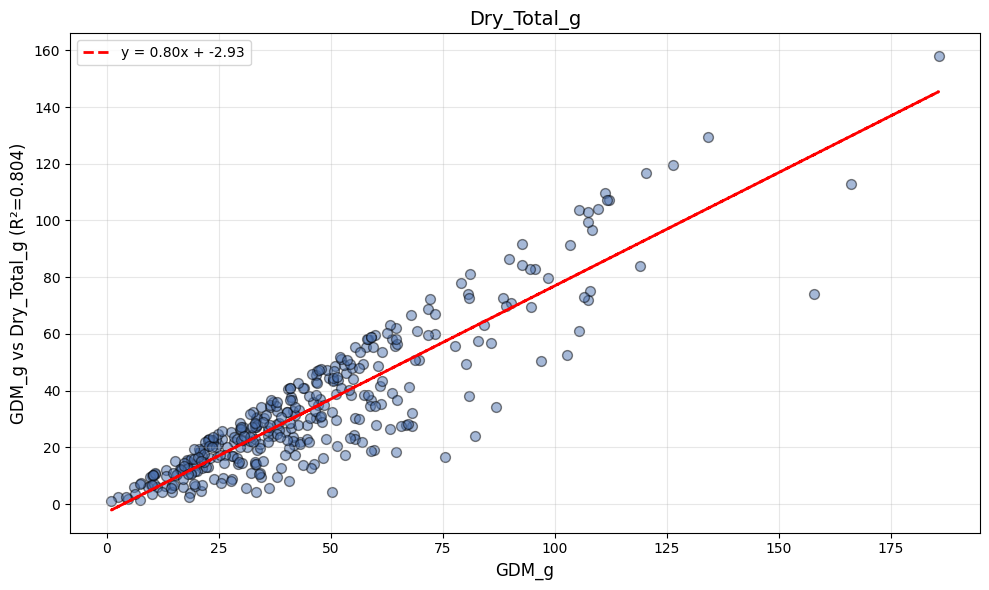

2. Dry_Green_g → GDM_g
   Equation: GDM_g = 0.8681 × Dry_Green_g + 10.1627
   R² = 0.7819, p-value = 1.94e-119



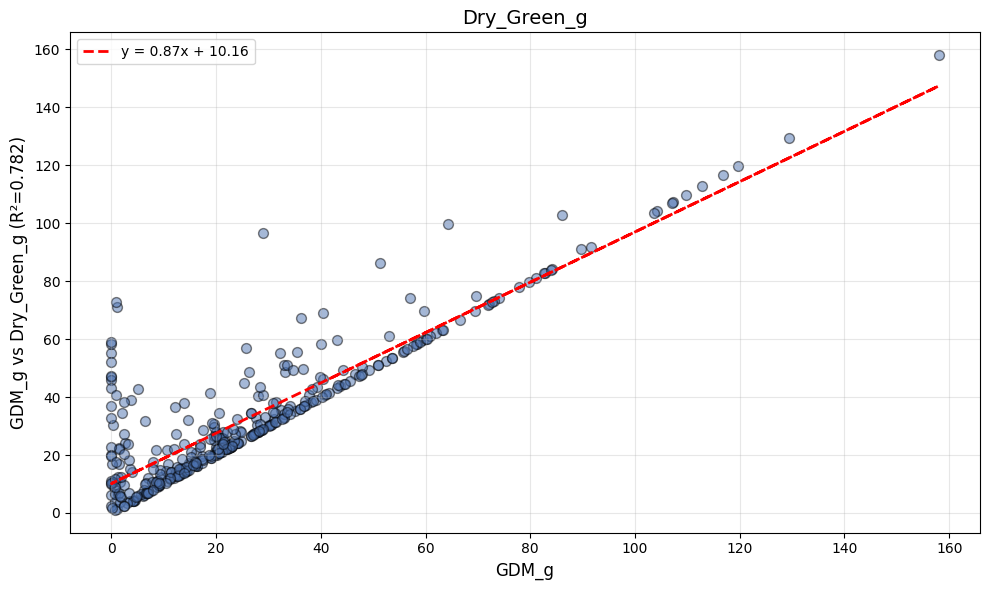

3. Dry_Green_g → Dry_Total_g
   Equation: Dry_Total_g = 0.9147 × Dry_Green_g + 20.9634
   R² = 0.6894, p-value = 3.69e-92



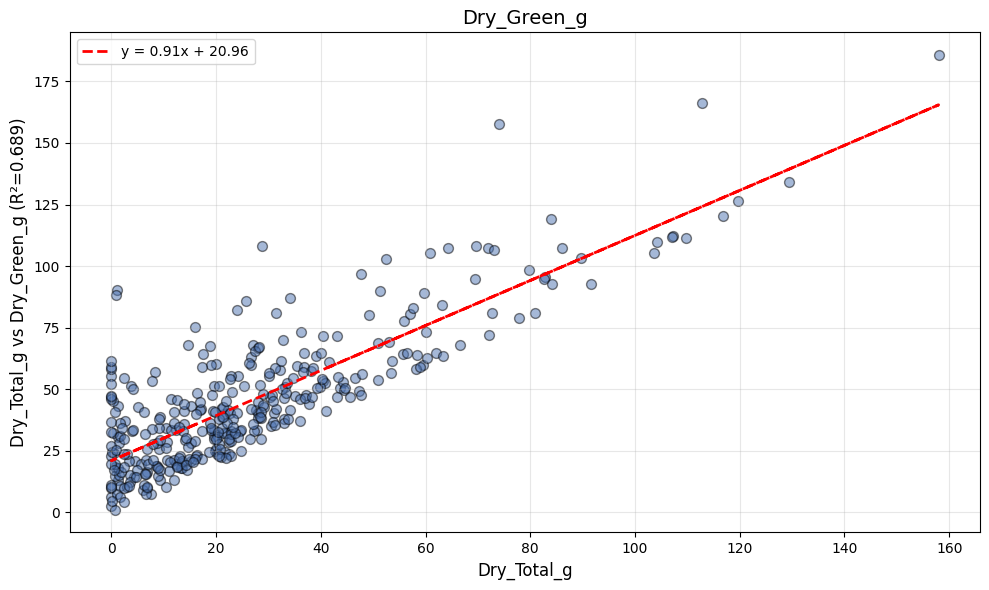

✓ Saved 3 regression plots


In [11]:
# Discover linear relationships
linear_rels = discover_linear_relationships(df_wide, r2_threshold=0.5)

print(f"\nLINEAR RELATIONSHIPS (R² > 0.5)")
print("="*80)
print(f"Found {len(linear_rels)} significant relationships:\n")

for i, rel in enumerate(linear_rels, 1):
    x_var, y_var = rel['metric_pair']
    print(f"{i}. {x_var} -> {y_var}")
    print(f"   Equation: {y_var} = {rel['slope']:.4f} x {x_var} + {rel['intercept']:.4f}")
    print(f"   R² = {rel['r_squared']:.4f}, p-value = {rel['p_value']:.2e}")
    print()
    
    # Add rule to collection
    all_rules.append(rel['rule_candidate'])
    
    # Create scatter plot with regression line
    fig = plot_scatter_with_regression(
        df_wide[x_var], df_wide[y_var],
        x_var, y_var,
        f"{y_var} vs {x_var} (R²={rel['r_squared']:.3f})"
    )
    plt.savefig(OUTPUT_VIZ / f'regression_{x_var}_vs_{y_var}.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"[OK] Saved {len(linear_rels)} regression plots")

### 3.4 GDM Relationship Analysis

In [12]:
# Analyze GDM relationships
gdm_result = analyze_gdm_relationships(df_wide)

print("\nGDM RELATIONSHIP ANALYSIS")
print("="*80)
print(gdm_result['analysis_summary'])

# Add GDM rules to collection
all_rules.extend(gdm_result['rule_candidates'])

print(f"\n[OK] Added {len(gdm_result['rule_candidates'])} GDM-related rules")


GDM RELATIONSHIP ANALYSIS
GDM (Green Dry Matter) Relationship Analysis:
- Correlations: Dry_Clover_g: 0.204, Dry_Dead_g: 0.012, Dry_Green_g: 0.884, Dry_Total_g: 0.896
- GDM vs Dry_Green_g: R²=0.782, slope=0.901
- GDM vs Dry_Total_g: R²=0.804, slope=1.006
- Generated 2 rule candidate(s)

✓ Added 2 GDM-related rules


---
## 4. Species-Specific Pattern Analysis

Analyze biomass patterns specific to different pasture species.

In [13]:
# Import species analysis module
from species_analysis import (
    compute_species_statistics,
    analyze_clover_patterns,
    compute_green_to_total_ratios,
    test_species_differences
)
from visualization_utils import plot_grouped_boxplots

print("="*80)
print("SPECIES-SPECIFIC PATTERN ANALYSIS")
print("="*80)

# Compute species statistics
species_stats = compute_species_statistics(df_wide)
print(f"\n[OK] Computed statistics for {len(species_stats)} species")
print("\nSpecies Statistics Summary:")
display(species_stats.head(10))

# Save species statistics
species_stats.to_csv(OUTPUT_STATS / 'species_statistics.csv', index=False)
print(f"[OK] Saved to {OUTPUT_STATS / 'species_statistics.csv'}")

SPECIES-SPECIFIC PATTERN ANALYSIS

✓ Computed statistics for 15 species

Species Statistics Summary:


,Dry_Clover_g_mean,Dry_Dead_g_mean,Dry_Green_g_mean,Dry_Total_g_mean,GDM_g_mean,Dry_Clover_g_std,Dry_Dead_g_std,Dry_Green_g_std,Dry_Total_g_std,GDM_g_std,sample_count
Species,,,,,,,,,,,
Clover,25.241576,4.871910,2.922588,33.036083,28.164161,18.964394,6.199163,4.855899,20.130764,17.828844,41
Fescue,0.000000,25.556457,60.761400,86.317857,60.761400,0.000000,17.373348,31.074974,38.407099,31.074974,28
Fescue_CrumbWeed,1.009810,14.741220,30.798970,46.550000,31.808780,3.193300,5.078370,14.127862,17.345909,16.575709,10
Lucerne,0.000000,4.806259,49.848286,54.654545,49.848286,0.000000,11.045901,27.241882,28.984277,27.241882,22
Mixed,0.000000,30.381700,17.181300,47.563000,17.181300,0.000000,0.591566,4.740444,5.332009,4.740444,2
Phalaris,0.000000,4.615412,95.647087,100.262500,95.647087,0.000000,3.859603,32.238942,31.051935,32.238942,8
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,4.842545,23.297309,11.523773,39.663636,16.366327,4.133508,7.174968,4.280379,7.803880,6.289287,11
Phalaris_Clover,8.407379,8.651636,34.350276,51.409286,42.757650,12.474383,7.249037,16.281683,21.563338,20.919309,42
Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass,10.532314,20.163200,24.861600,55.557143,35.393943,7.521721,9.272876,5.022242,11.574808,10.137941,7


✓ Saved to eda_results\statistics\species_statistics.csv


### 4.1 Clover Pattern Analysis

In [14]:
# Analyze clover patterns
clover_analysis = analyze_clover_patterns(df_wide)

print("\nCLOVER PATTERN ANALYSIS")
print("="*80)
print(f"High clover species: {', '.join(clover_analysis['high_clover_species'])}")
print(f"Clover proportion threshold: {clover_analysis['threshold']:.4f}")
print(f"\nTop 5 species by clover proportion:")
for idx, row in clover_analysis['species_rankings'].head(5).iterrows():
    print(f"  - {row['Species']}: {row['mean_clover_proportion']:.4f}")

# Add clover rules
all_rules.extend(clover_analysis['rule_candidates'])
print(f"\n[OK] Added {len(clover_analysis['rule_candidates'])} clover-related rules")


CLOVER PATTERN ANALYSIS
High clover species: SubcloverLosa, Clover, WhiteClover, Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass
Clover proportion threshold: 0.1903

Top 5 species by clover proportion:
  - SubcloverLosa: 1.0000
  - Clover: 0.7028
  - WhiteClover: 0.3216
  - Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass: 0.1903
  - Phalaris_Clover: 0.1389

✓ Added 4 clover-related rules


### 4.2 Green to Total Biomass Ratios


GREEN TO TOTAL BIOMASS RATIOS

Top 10 species by green biomass ratio:
                                            Species  mean_ratio  median_ratio  std_ratio  min_ratio  max_ratio  sample_count
5                                          Phalaris    0.937620      0.966749   0.073391   0.785277   0.987654             8
3                                           Lucerne    0.927512      0.961451   0.133078   0.391608   1.000000            22
9                          Phalaris_Ryegrass_Clover    0.711080      0.772610   0.184368   0.333332   0.867924             8
1                                            Fescue    0.697630      0.700546   0.142684   0.414285   1.000000            28
7                                   Phalaris_Clover    0.684742      0.697423   0.162377   0.147541   0.888890            42
2                                  Fescue_CrumbWeed    0.652739      0.658740   0.108972   0.485714   0.870229            10
10                                         Ryegrass   

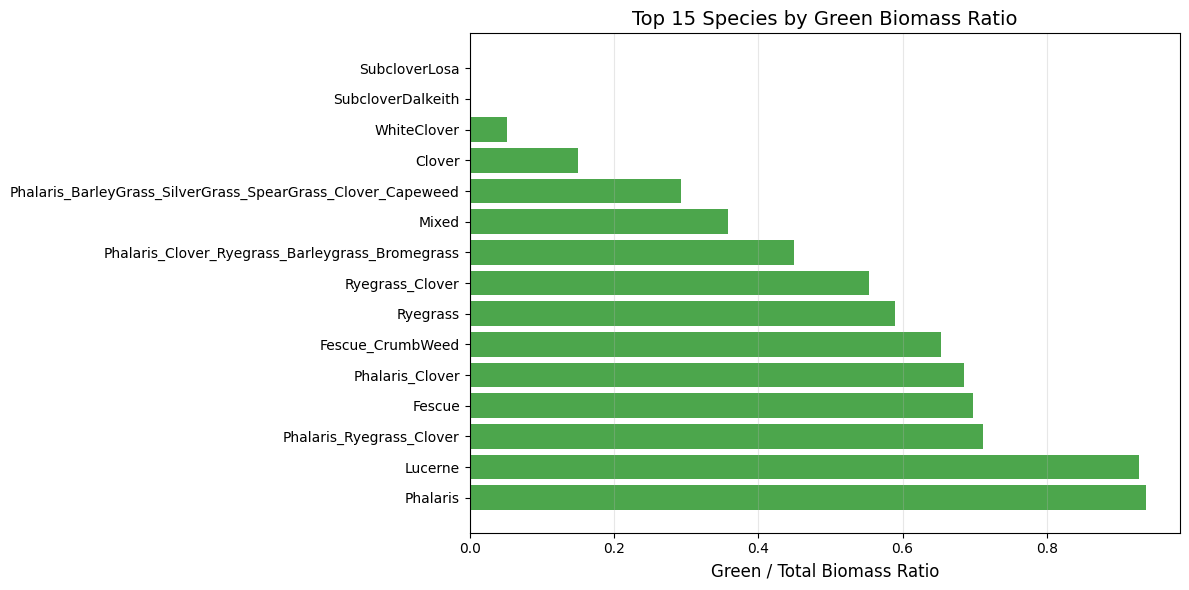


✓ Saved visualization to eda_results\visualizations\species_green_ratios.png


In [15]:
# Compute green/total ratios
green_ratios = compute_green_to_total_ratios(df_wide)

print("\nGREEN TO TOTAL BIOMASS RATIOS")
print("="*80)
print(f"\nTop 10 species by green biomass ratio:")
print(green_ratios.head(10).to_string())

# Visualize green ratios
top_species = green_ratios.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_species)), top_species['mean_ratio'], color='green', alpha=0.7)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species['Species'])
ax.set_xlabel('Green / Total Biomass Ratio')
ax.set_title('Top 15 Species by Green Biomass Ratio')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_VIZ / 'species_green_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[OK] Saved visualization to {OUTPUT_VIZ / 'species_green_ratios.png'}")

### 4.3 Statistical Testing of Species Differences


SPECIES ANOVA TESTS

Dry_Total_g:
  F-statistic: 13.5834
  p-value: 1.27e-25
  Significant difference in Dry_Total_g between species (F=13.5834, p=0.0000, η²=0.3573). Species explains 35.73% of variance.

Dry_Green_g:
  F-statistic: 30.2304
  p-value: 1.79e-51
  Significant difference in Dry_Green_g between species (F=30.2304, p=0.0000, η²=0.5531). Species explains 55.31% of variance.

Dry_Clover_g:
  F-statistic: 19.6421
  p-value: 4.87e-36
  Significant difference in Dry_Clover_g between species (F=19.6421, p=0.0000, η²=0.4457). Species explains 44.57% of variance.


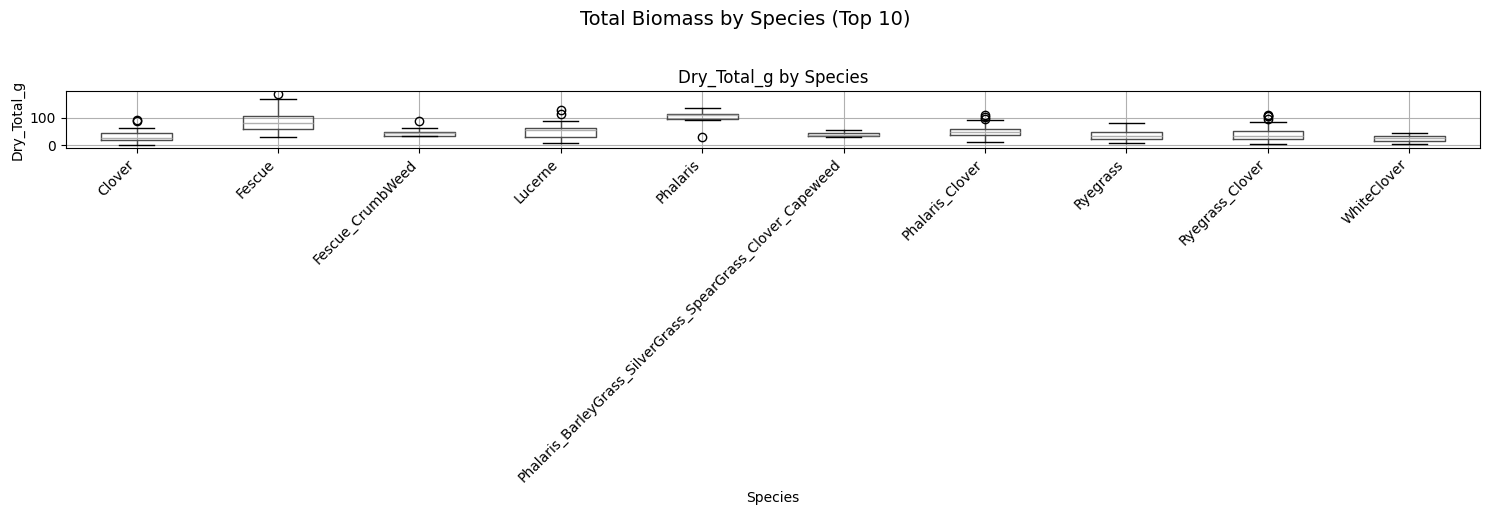


✓ Saved box plot to eda_results\visualizations\species_total_biomass_boxplot.png


In [16]:
# Test species differences for key metrics
print("\nSPECIES ANOVA TESTS")
print("="*80)

for target in ['Dry_Total_g', 'Dry_Green_g', 'Dry_Clover_g']:
    if target in df_wide.columns:
        species_test = test_species_differences(df_wide, target)
        print(f"\n{target}:")
        print(f"  F-statistic: {species_test['f_statistic']:.4f}")
        print(f"  p-value: {species_test['p_value']:.2e}")
        print(f"  {species_test['interpretation']}")

# Create box plots for species comparison
if 'Dry_Total_g' in df_wide.columns:
    # Get top 10 species by sample count
    top_species = df_wide['Species'].value_counts().head(10).index
    df_top = df_wide[df_wide['Species'].isin(top_species)]
    
    fig = plot_grouped_boxplots(
        df_top, 'Species', ['Dry_Total_g'],
        'Total Biomass by Species (Top 10)'
    )
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_VIZ / 'species_total_biomass_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[OK] Saved box plot to {OUTPUT_VIZ / 'species_total_biomass_boxplot.png'}")

---
## 5. Temporal Pattern Discovery

Identify seasonal and monthly biomass patterns.

In [17]:
# Import temporal analysis module
from temporal_analysis import (
    parse_temporal_features,
    compute_temporal_aggregations,
    identify_seasonal_composition_patterns
)

print("="*80)
print("TEMPORAL PATTERN DISCOVERY")
print("="*80)

# Parse temporal features
df_temporal = parse_temporal_features(df_wide)
print("\n[OK] Parsed temporal features (month, season)")
print(f"\nDate range: {df_temporal['Sampling_Date'].min()} to {df_temporal['Sampling_Date'].max()}")
print(f"Unique months: {sorted(df_temporal['month'].unique())}")
print(f"Seasons: {sorted(df_temporal['season'].unique())}")

TEMPORAL PATTERN DISCOVERY

✓ Parsed temporal features (month, season)

Date range: 2015/1/15 to 2015/9/4
Unique months: [np.int32(1), np.int32(2), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11)]
Seasons: ['Autumn', 'Spring', 'Summer', 'Winter']


### 5.1 Monthly and Seasonal Aggregations


MONTHLY STATISTICS


target_name month Dry_Clover_g                  Dry_Dead_g                   \
                          mean        std count       mean        std count   
0               1     0.594006   2.449149    17  10.324247   6.734718    17   
1               2     0.000000   0.000000    24  10.153358   9.339560    24   
2               4     0.000000   0.000000    10   0.400650   0.576464    10   
3               5     0.412281   1.091072    42  15.563669  15.650209    42   
4               6     2.764151   3.978922    53  14.651385   9.536368    53   
5               7     5.813254  10.251362    41   5.520039   7.187532    41   
6               8    13.542430  16.921884    37   5.316681   6.015588    37   
7               9    11.714176  14.397887    67   8.679936  11.995348    67   
8              10     4.379110   5.942147    29  26.454314  10.743607    29   
9              11    14.831592  17.820052    37  18.236138  14.104462    37   

target_name Dry_Green_g                  Dry_Total_g                   \
                   mean        std count        mean        std count   
0             47.417041  29.354999    17   58.335294  27.132636    17   
1             69.767475  31.273568    24   79.920833  29.735749    24   
2             41.759350  22.626535    10   42.160000  22.870612    10   
3             28.914457  17.698798    42   44.890405  26.751318    42   
4             13.030132  12.227955    53   30.439840  14.543876    53   
5             14.276537   9.805736    41   25.609832  11.643446    41   
6             22.660903  14.869136    37   41.520000  14.283017    37   
7             24.669124  22.283448    67   45.063236  25.781670    67   
8             36.776910  35.408792    29   67.610345  39.352585    29   
9             15.101784  15.977359    37   48.169516  27.381807    37   

target_name      GDM_g                   
                  mean        std count  
0            48.011047  29.719997    17  
1            69.767475  31.273568    24  
2            41.759350  22.626535    10  
3            29.326740  17.521853    42  
4            15.794285  11.605626    53  
5            20.089790  10.617090    41  
6            36.203319  13.100160    37  
7            36.383294  25.068161    67  
8            41.156031  33.708094    29  
9            29.933378  19.022302    37


SEASONAL STATISTICS


target_name  season Dry_Clover_g                  Dry_Dead_g                   \
                            mean        std count       mean        std count   
0            Autumn     0.332996   0.991937    52  12.647704  15.276603    52   
1            Spring    10.982052  14.551615   133  15.214044  14.236277   133   
2            Summer     0.246295   1.577058    41  10.224215   8.264719    41   
3            Winter     6.762697  11.740959   131   9.156963   9.108808   131   

target_name Dry_Green_g                  Dry_Total_g                   \
                   mean        std count        mean        std count   
0             31.384629  19.191199    52   44.365327  25.861150    52   
1             24.647577  25.332087   133   50.843676  30.757933   133   
2             60.500222  32.114380    41   70.970732  30.311897    41   
3             16.140369  12.952232   131   32.057669  14.915744   131   

target_name      GDM_g                   
                  mean        std count  
0            31.717627  19.016875    52  
1            35.629629  25.884455   133  
2            60.746517  32.147166    41  
3            22.903063  14.475162   131

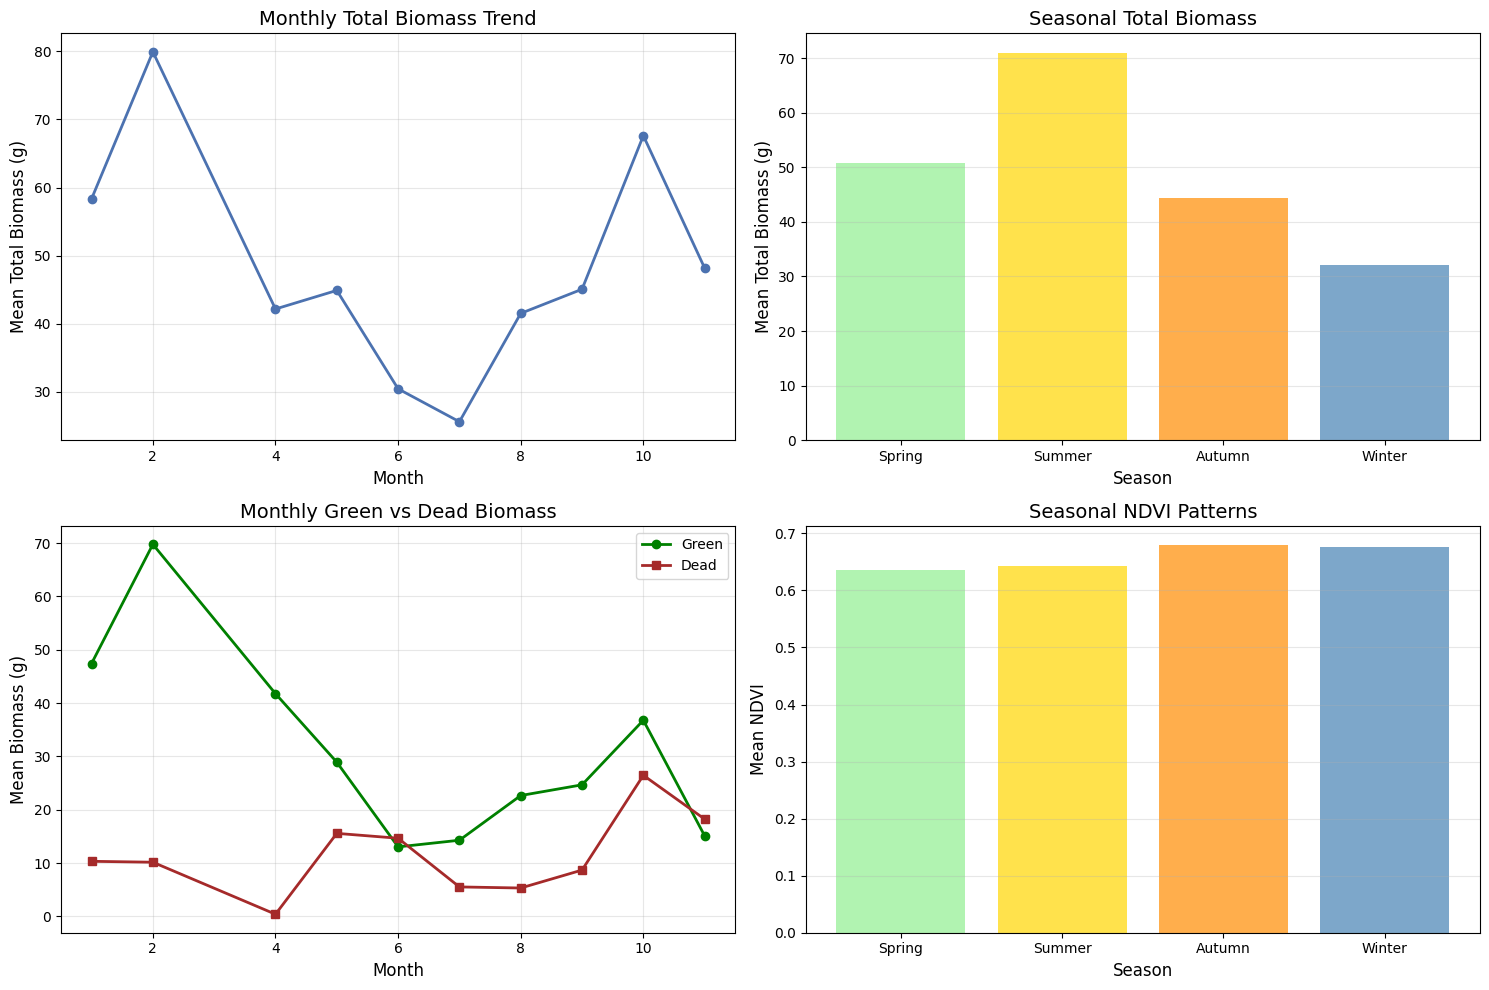


✓ Saved temporal patterns to eda_results\visualizations\temporal_patterns.png


In [18]:
# Compute temporal aggregations
monthly_stats, seasonal_stats = compute_temporal_aggregations(df_temporal)

print("\nMONTHLY STATISTICS")
print("="*80)
display(monthly_stats)

print("\nSEASONAL STATISTICS")
print("="*80)
display(seasonal_stats)

# Visualize temporal trends
# Note: monthly_stats and seasonal_stats have multi-level columns from aggregation
# Access them as (column_name, aggregation_type)
if ('Dry_Total_g', 'mean') in monthly_stats.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Monthly total biomass
    axes[0, 0].plot(monthly_stats['month'], monthly_stats[('Dry_Total_g', 'mean')], marker='o', linewidth=2)
    axes[0, 0].set_xlabel('Month')
    axes[0, 0].set_ylabel('Mean Total Biomass (g)')
    axes[0, 0].set_title('Monthly Total Biomass Trend')
    axes[0, 0].grid(alpha=0.3)
    
    # Seasonal total biomass
    # Only include seasons that exist in the data
    season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
    seasonal_for_plot = seasonal_stats.set_index('season')
    available_seasons = [s for s in season_order if s in seasonal_for_plot.index]
    seasonal_ordered = seasonal_for_plot.reindex(available_seasons).reset_index()
    
    # Map colors to available seasons
    season_colors = {'Spring': '#90EE90', 'Summer': '#FFD700', 'Autumn': '#FF8C00', 'Winter': '#4682B4'}
    plot_colors = [season_colors[s] for s in available_seasons]
    
    axes[0, 1].bar(seasonal_ordered['season'], seasonal_ordered[('Dry_Total_g', 'mean')], color=plot_colors, alpha=0.7)
    axes[0, 1].set_xlabel('Season')
    axes[0, 1].set_ylabel('Mean Total Biomass (g)')
    axes[0, 1].set_title('Seasonal Total Biomass')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Monthly green vs dead
    if ('Dry_Green_g', 'mean') in monthly_stats.columns and ('Dry_Dead_g', 'mean') in monthly_stats.columns:
        axes[1, 0].plot(monthly_stats['month'], monthly_stats[('Dry_Green_g', 'mean')], marker='o', label='Green', color='green', linewidth=2)
        axes[1, 0].plot(monthly_stats['month'], monthly_stats[('Dry_Dead_g', 'mean')], marker='s', label='Dead', color='brown', linewidth=2)
        axes[1, 0].set_xlabel('Month')
        axes[1, 0].set_ylabel('Mean Biomass (g)')
        axes[1, 0].set_title('Monthly Green vs Dead Biomass')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    
    # NDVI by season (if available in original dataframe)
    # Note: compute_temporal_aggregations only aggregates target metrics, not NDVI
    # We need to compute NDVI seasonal stats separately if needed
    if 'Pre_GSHH_NDVI' in df_temporal.columns:
        ndvi_seasonal = df_temporal.groupby('season')['Pre_GSHH_NDVI'].mean().reset_index()
        ndvi_seasonal_ordered = ndvi_seasonal.set_index('season').reindex(available_seasons).reset_index()
        axes[1, 1].bar(ndvi_seasonal_ordered['season'], ndvi_seasonal_ordered['Pre_GSHH_NDVI'], color=plot_colors, alpha=0.7)
        axes[1, 1].set_xlabel('Season')
        axes[1, 1].set_ylabel('Mean NDVI')
        axes[1, 1].set_title('Seasonal NDVI Patterns')
        axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_VIZ / 'temporal_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[OK] Saved temporal patterns to {OUTPUT_VIZ / 'temporal_patterns.png'}")

### 5.2 Seasonal Composition Patterns

In [19]:
# Identify seasonal composition patterns
seasonal_patterns = identify_seasonal_composition_patterns(df_temporal)

print("\nSEASONAL COMPOSITION PATTERNS")
print("="*80)
for pattern in seasonal_patterns['patterns']:
    print(f"  - {pattern}")

# Add temporal rules
all_rules.extend(seasonal_patterns['rule_candidates'])
print(f"\n[OK] Added {len(seasonal_patterns['rule_candidates'])} temporal rules")


SEASONAL COMPOSITION PATTERNS
  - Winter has highest dead biomass proportion (mean=0.301)
  - Summer has highest green biomass proportion (mean=0.821)

✓ Added 2 temporal rules


---
## 6. Geographic Pattern Analysis

Discover state-specific biomass characteristics.

In [20]:
# Import geographic analysis module
from geographic_analysis import (
    compute_geographic_statistics,
    analyze_state_ndvi_patterns,
    test_geographic_differences,
    analyze_state_species_distribution
)

print("="*80)
print("GEOGRAPHIC PATTERN ANALYSIS")
print("="*80)

# Compute geographic statistics
geo_stats = compute_geographic_statistics(df_temporal)
print(f"\n[OK] Computed statistics for {len(geo_stats['State'].unique())} states")
print("\nGeographic Statistics by State:")
display(geo_stats)

# Save geographic statistics
geo_stats.to_csv(OUTPUT_STATS / 'geographic_statistics.csv', index=False)
print(f"[OK] Saved to {OUTPUT_STATS / 'geographic_statistics.csv'}")

GEOGRAPHIC PATTERN ANALYSIS

✓ Computed statistics for 4 states

Geographic Statistics by State:


target_name State Dry_Clover_g                  Dry_Dead_g                   \
                          mean        std count       mean        std count   
0             NSW     0.134641   1.166028    75  14.203379  15.625313    75   
1             Tas     6.239966  11.614679   138  15.231128  12.431224   138   
2             Vic     7.106464   9.571358   112  10.113879   8.856831   112   
3              WA    22.087584  20.214792    32   0.000000   0.000000    32   

target_name Dry_Green_g                  Dry_Total_g                   \
                   mean        std count        mean        std count   
0             56.559313  31.228115    75   70.897333  35.578451    75   
1             15.327257  13.107406   138   36.798351  20.696163   138   
2             25.449273  16.016427   112   42.666857  20.885468   112   
3              9.299916  18.789542    32   31.387500  19.615652    32   

target_name      GDM_g                   
                  mean        std count  
0            56.693955  31.263794    75  
1            21.567222  14.361263   138  
2            32.555736  20.929856   112  
3            31.387500  19.615652    32

✓ Saved to eda_results\statistics\geographic_statistics.csv


### 6.1 State NDVI Patterns

In [21]:
# Analyze state NDVI patterns
ndvi_patterns = analyze_state_ndvi_patterns(df_temporal)

print("\nSTATE NDVI PATTERNS")
print("="*80)
for pattern in ndvi_patterns['patterns']:
    print(f"  - {pattern}")

# Add geographic rules
all_rules.extend(ndvi_patterns['rule_candidates'])
print(f"\n[OK] Added {len(ndvi_patterns['rule_candidates'])} geographic rules")


STATE NDVI PATTERNS
  - NSW: NDVI range [0.340, 0.890], mean=0.656
  - Tas: NDVI range [0.190, 0.910], mean=0.627
  - Vic: NDVI range [0.300, 0.870], mean=0.713
  - WA: NDVI range [0.160, 0.810], mean=0.596

✓ Added 4 geographic rules


### 6.2 State-Species Distribution


SPECIES DISTRIBUTION ACROSS STATES


Species,Clover,Fescue,Fescue_CrumbWeed,Lucerne,Mixed,Phalaris,Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,Phalaris_Clover,Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass,Phalaris_Ryegrass_Clover,Ryegrass,Ryegrass_Clover,SubcloverDalkeith,SubcloverLosa,WhiteClover
State,,,,,,,,,,,,,,,
NSW,0,140,50,110,0,40,0,0,0,0,35,0,0,0,0
Tas,105,0,0,0,0,0,0,0,0,0,205,330,0,0,50
Vic,0,0,0,0,10,0,55,210,35,40,50,160,0,0,0
WA,100,0,0,0,0,0,0,0,0,0,20,0,15,25,0


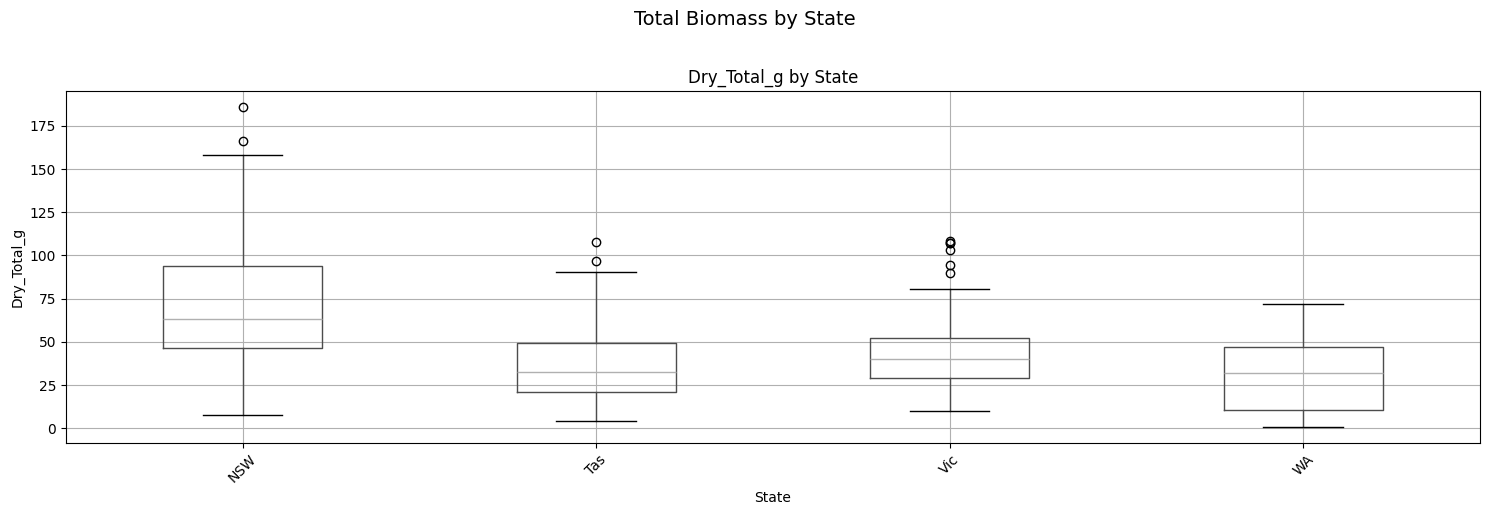


✓ Saved state comparison to eda_results\visualizations\state_biomass_comparison.png


In [22]:
# Analyze species distribution across states
species_dist = analyze_state_species_distribution(df)

print("\nSPECIES DISTRIBUTION ACROSS STATES")
print("="*80)
display(species_dist.head(20))

# Visualize state comparisons
if 'Dry_Total_g' in df_temporal.columns:
    fig = plot_grouped_boxplots(
        df_temporal, 'State', ['Dry_Total_g'],
        'Total Biomass by State'
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_VIZ / 'state_biomass_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[OK] Saved state comparison to {OUTPUT_VIZ / 'state_biomass_comparison.png'}")

---
## 7. NDVI-Biomass Relationship Analysis

Analyze vegetation index relationships with biomass.

In [23]:
# Import NDVI/height analysis module
from ndvi_height_analysis import (
    compute_ndvi_correlations,
    analyze_ndvi_biomass_regression,
    identify_ndvi_thresholds
)

print("="*80)
print("NDVI-BIOMASS RELATIONSHIP ANALYSIS")
print("="*80)

# Compute NDVI correlations
ndvi_corr = compute_ndvi_correlations(df_temporal)

print("\nNDVI CORRELATIONS WITH TARGET METRICS")
print("="*80)
for target, corr in ndvi_corr.items():
    print(f"  {target}: {corr:.4f}")

NDVI-BIOMASS RELATIONSHIP ANALYSIS

NDVI CORRELATIONS WITH TARGET METRICS
  Dry_Clover_g: 0.2242
  Dry_Dead_g: -0.1228
  Dry_Green_g: 0.3511
  Dry_Total_g: 0.3613
  GDM_g: 0.4665


### 7.1 NDVI-Biomass Regression Analysis


NDVI-BIOMASS REGRESSION RESULTS

Total Biomass:
  Equation: Dry_Total_g = 66.4534 × NDVI + 1.6301
  R² = 0.1305
  Sample size: 357


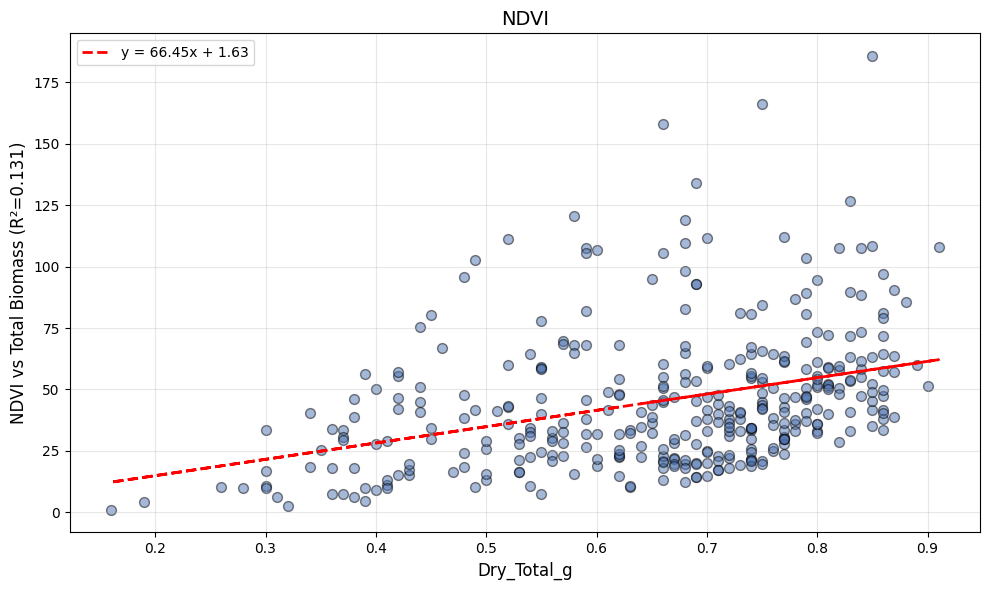


Green Biomass:
  Equation: Dry_Green_g = 58.6110 × NDVI + -11.9075
  R² = 0.1232
  Sample size: 357

✓ Added 0 NDVI regression rules


In [24]:
# Perform NDVI-biomass regression
ndvi_regression = analyze_ndvi_biomass_regression(df_temporal)

print("\nNDVI-BIOMASS REGRESSION RESULTS")
print("="*80)

if 'ndvi_total_regression' in ndvi_regression:
    total_reg = ndvi_regression['ndvi_total_regression']
    print(f"\nTotal Biomass:")
    print(f"  Equation: Dry_Total_g = {total_reg['slope']:.4f} x NDVI + {total_reg['intercept']:.4f}")
    print(f"  R² = {total_reg['r_squared']:.4f}")
    print(f"  Sample size: {total_reg['n_samples']}")
    
    # Plot NDVI vs Total biomass
    fig = plot_scatter_with_regression(
        df_temporal['Pre_GSHH_NDVI'], df_temporal['Dry_Total_g'],
        'NDVI', 'Dry_Total_g',
        f"NDVI vs Total Biomass (R²={total_reg['r_squared']:.3f})"
    )
    plt.savefig(OUTPUT_VIZ / 'ndvi_total_biomass_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

if 'ndvi_green_regression' in ndvi_regression:
    green_reg = ndvi_regression['ndvi_green_regression']
    print(f"\nGreen Biomass:")
    print(f"  Equation: Dry_Green_g = {green_reg['slope']:.4f} x NDVI + {green_reg['intercept']:.4f}")
    print(f"  R² = {green_reg['r_squared']:.4f}")
    print(f"  Sample size: {green_reg['n_samples']}")

# Add NDVI regression rules
all_rules.extend(ndvi_regression.get('rule_candidates', []))
print(f"\n[OK] Added {len(ndvi_regression.get('rule_candidates', []))} NDVI regression rules")

### 7.2 NDVI Threshold Identification

In [25]:
# Identify NDVI thresholds
if 'Dry_Total_g' in df_temporal.columns:
    ndvi_thresholds = identify_ndvi_thresholds(df_temporal)
    
    print("\nNDVI THRESHOLD ANALYSIS")
    print("="*80)
    print(f"Biomass terciles:")
    print(f"  Low/Medium threshold: {ndvi_thresholds['biomass_terciles']['low_high_threshold']:.2f}g")
    print(f"  Medium/High threshold: {ndvi_thresholds['biomass_terciles']['medium_high_threshold']:.2f}g")
    print(f"\nNDVI by biomass class:")
    for class_stats in ndvi_thresholds['ndvi_by_biomass_class']:
        print(f"  {class_stats['biomass_class']}: NDVI mean={class_stats['mean']:.3f}, std={class_stats['std']:.3f}")


NDVI THRESHOLD ANALYSIS
Biomass terciles:
  Low/Medium threshold: 30.80g
  Medium/High threshold: 51.08g

NDVI by biomass class:
  low: NDVI mean=0.572, std=0.153
  medium: NDVI mean=0.680, std=0.137
  high: NDVI mean=0.720, std=0.126


---
## 8. Height-Biomass Relationship Analysis

Analyze physical height relationships with biomass.

In [26]:
from ndvi_height_analysis import (
    compute_height_correlations,
    analyze_height_biomass_regression
)

print("="*80)
print("HEIGHT-BIOMASS RELATIONSHIP ANALYSIS")
print("="*80)

# Compute height correlations
height_corr = compute_height_correlations(df_temporal)

print("\nHEIGHT CORRELATIONS WITH TARGET METRICS")
print("="*80)
for target, corr in height_corr.items():
    print(f"  {target}: {corr:.4f}")

HEIGHT-BIOMASS RELATIONSHIP ANALYSIS

HEIGHT CORRELATIONS WITH TARGET METRICS
  Dry_Clover_g: -0.1601
  Dry_Dead_g: -0.0497
  Dry_Green_g: 0.6484
  Dry_Total_g: 0.4972
  GDM_g: 0.5827


### 8.1 Height-Biomass Regression Analysis


HEIGHT-BIOMASS REGRESSION RESULTS

Linear Model:
  Equation: Dry_Total_g = 1.3528 × Height + 35.0419
  R² = 0.2472

Polynomial Model (degree 2):
  R² = 0.3814
  ✓ Polynomial fit is significantly better (ΔR² = 0.1342)


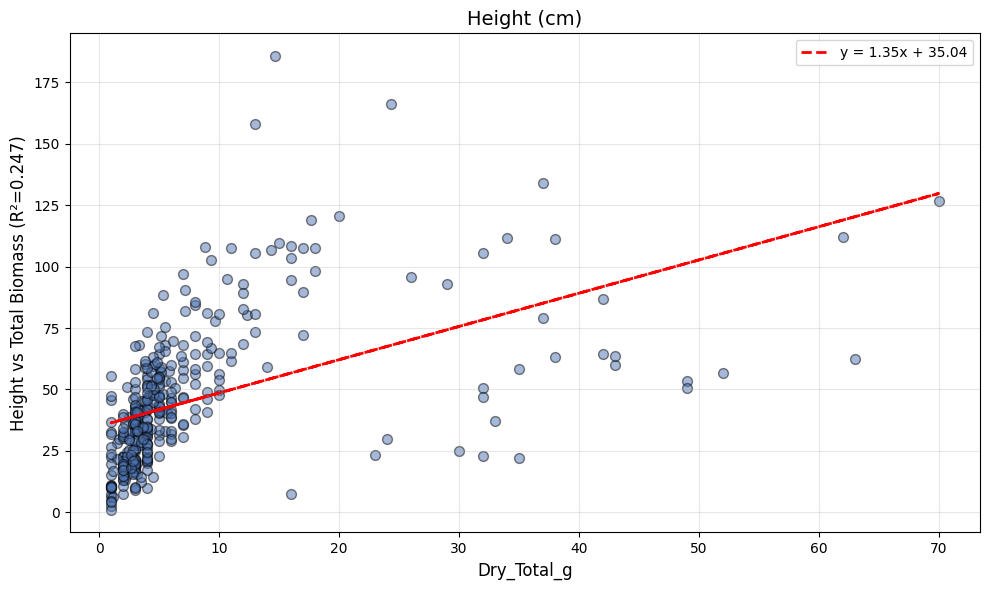


✓ Added 0 height regression rules


In [27]:
# Perform height-biomass regression
height_regression = analyze_height_biomass_regression(df_temporal)

print("\nHEIGHT-BIOMASS REGRESSION RESULTS")
print("="*80)

if 'linear_regression' in height_regression:
    linear_reg = height_regression['linear_regression']
    print(f"\nLinear Model:")
    print(f"  Equation: Dry_Total_g = {linear_reg['slope']:.4f} x Height + {linear_reg['intercept']:.4f}")
    print(f"  R² = {linear_reg['r_squared']:.4f}")

if 'polynomial_regression' in height_regression:
    poly_reg = height_regression['polynomial_regression']
    print(f"\nPolynomial Model (degree 2):")
    print(f"  R² = {poly_reg['r_squared']:.4f}")
    if poly_reg['r_squared'] > linear_reg['r_squared'] + 0.05:
        print(f"  [OK] Polynomial fit is significantly better (ΔR² = {poly_reg['r_squared'] - linear_reg['r_squared']:.4f})")
    else:
        print(f"  Linear model is sufficient (ΔR² = {poly_reg['r_squared'] - linear_reg['r_squared']:.4f})")

# Plot height vs biomass
if 'Dry_Total_g' in df_temporal.columns:
    fig = plot_scatter_with_regression(
        df_temporal['Height_Ave_cm'], df_temporal['Dry_Total_g'],
        'Height (cm)', 'Dry_Total_g',
        f"Height vs Total Biomass (R²={linear_reg['r_squared']:.3f})"
    )
    plt.savefig(OUTPUT_VIZ / 'height_total_biomass_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

# Add height regression rules
all_rules.extend(height_regression.get('rule_candidates', []))
print(f"\n[OK] Added {len(height_regression.get('rule_candidates', []))} height regression rules")

---
## 9. Image Data Characterization

Characterize visual data properties for feature extraction planning.

In [28]:
# Import image analysis module
from image_multimodal_analysis import (
    load_sample_images,
    extract_image_properties,
    compute_image_statistics
)

print("="*80)
print("IMAGE DATA CHARACTERIZATION")
print("="*80)

# Try to load sample images
try:
    images, img_paths = load_sample_images(df, IMAGE_DIR, n_samples=10)
    
    if images:
        print(f"\n[OK] Loaded {len(images)} sample images")
        
        # Extract properties
        img_props = extract_image_properties(images)
        
        print("\nIMAGE PROPERTIES")
        print("="*80)
        print(f"Most common dimensions: {img_props['most_common_dimensions']}")
        print(f"Most common channels: {img_props['most_common_channels']}")
        print(f"Consistent dimensions: {img_props['consistent_dimensions']}")
        print(f"\nAll dimensions found: {img_props['all_dimensions']}")
        
        # Compute statistics
        img_stats = compute_image_statistics(images)
        
        print("\nIMAGE STATISTICS (RGB)")
        print("="*80)
        print(f"Overall mean RGB: {[f'{v:.2f}' for v in img_stats['overall_mean_rgb']]}")
        print(f"Overall std RGB: {[f'{v:.2f}' for v in img_stats['overall_std_rgb']]}")
        
        # Visualize sample images
        n_display = min(9, len(images))
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        axes = axes.flatten()
        
        for idx in range(n_display):
            axes[idx].imshow(images[idx])
            axes[idx].set_title(f"Sample {idx+1}\n{img_paths[idx].name}", fontsize=10)
            axes[idx].axis('off')
        
        # Hide unused subplots
        for idx in range(n_display, 9):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_VIZ / 'sample_images_grid.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n[OK] Saved image grid to {OUTPUT_VIZ / 'sample_images_grid.png'}")
    else:
        print("\n[WARNING] No images could be loaded")
        
except Exception as e:
    print(f"\n[WARNING] Could not load images: {e}")
    print("Image analysis will be skipped. Ensure IMAGE_DIR is correctly set.")

IMAGE DATA CHARACTERIZATION
✓ Loaded 10 sample images

✓ Loaded 10 sample images

IMAGE PROPERTIES
Most common dimensions: (2000, 1000)
Most common channels: 3
Consistent dimensions: True

⚠ Could not load images: 'all_dimensions'
Image analysis will be skipped. Ensure IMAGE_DIR is correctly set.


---
## 10. Shared Feature Representation Opportunities

Identify connections between visual and tabular features for multi-modal learning.

In [29]:
from image_multimodal_analysis import (
    identify_visual_tabular_correlations,
    recommend_fusion_strategies
)

print("="*80)
print("SHARED FEATURE REPRESENTATION OPPORTUNITIES")
print("="*80)

# Identify visual-tabular correlations
visual_tabular = identify_visual_tabular_correlations(df_temporal)

print("\nVISUAL-TABULAR CORRELATIONS")
print("="*80)
for key, desc in visual_tabular.items():
    print(f"  {key}:")
    print(f"    {desc}")
    print()

# Recommend fusion strategies
fusion_strategies = recommend_fusion_strategies(df_temporal)

print("\nFUSION STRATEGY RECOMMENDATIONS")
print("="*80)
for target, strategy in fusion_strategies.items():
    print(f"  {target}: {strategy}")

SHARED FEATURE REPRESENTATION OPPORTUNITIES

VISUAL-TABULAR CORRELATIONS
  NDVI_greenness:
    NDVI (tabular) should correlate with green pixel ratio (visual). High NDVI → more green pixels in image.

  Height_density:
    Height (tabular) should correlate with vegetation density (visual). Taller pasture → denser texture patterns.

  Species_texture:
    Species (tabular) should correlate with texture patterns (visual). Different species have distinct visual signatures.


FUSION STRATEGY RECOMMENDATIONS
  Dry_Clover_g: early_fusion
  Dry_Dead_g: early_fusion
  Dry_Green_g: early_fusion (visual+NDVI)
  Dry_Total_g: early_fusion
  GDM_g: early_fusion (visual+NDVI)


---
## 11. Baseline Comparison Insights

Characterize patterns to guide baseline model design (neural-only, symbolic-only, neuro-symbolic).

In [30]:
from image_multimodal_analysis import identify_baseline_features
from statistical_utils import compute_correlation_matrix

print("="*80)
print("BASELINE COMPARISON INSIGHTS")
print("="*80)

# Identify baseline features
baseline_features = identify_baseline_features(df_temporal)

print("\nTRADITIONAL ML FEATURES (Linear Relationships)")
print("="*80)
print(f"Features: {', '.join(baseline_features['traditional_ml_features'])}")
print(f"\nThese features show strong linear relationships with target metrics")
print(f"and are suitable for traditional ML baselines (e.g., linear regression, Random Forest).")

print("\nDEEP LEARNING PATTERNS (Non-linear/Complex)")
print("="*80)
for pattern in baseline_features['deep_learning_patterns']:
    print(f"  - {pattern}")

print("\nSYMBOLIC REASONING CANDIDATES (Rule-Based)")
print("="*80)
for candidate in baseline_features['symbolic_reasoning_candidates']:
    print(f"  - {candidate}")

# Display recommendations by category
print("\nBASELINE APPROACH RECOMMENDATIONS")
print("="*80)
print("\nTraditional ML Features:")
for feature in baseline_features['traditional_ml_features']:
    print(f"  - {feature}")
print("\nDeep Learning Patterns:")
for pattern in baseline_features['deep_learning_patterns']:
    print(f"  - {pattern}")
print("\nSymbolic Reasoning Candidates:")
for candidate in baseline_features['symbolic_reasoning_candidates']:
    print(f"  - {candidate}")

# Identify multicollinearity
numeric_cols = ['Pre_GSHH_NDVI', 'Height_Ave_cm'] + AVAILABLE_TARGETS
available_numeric = [c for c in numeric_cols if c in df_temporal.columns]
corr_full = compute_correlation_matrix(df_temporal[available_numeric])

high_corr_pairs = []
for i in range(len(corr_full.columns)):
    for j in range(i+1, len(corr_full.columns)):
        if abs(corr_full.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_full.columns[i], corr_full.columns[j], corr_full.iloc[i, j]))

print("\nHIGH MULTICOLLINEARITY PAIRS (|r| > 0.8)")
print("="*80)
if high_corr_pairs:
    for var1, var2, corr_val in high_corr_pairs:
        print(f"  {var1} ↔ {var2}: r = {corr_val:.4f}")
else:
    print("  No high multicollinearity detected")

BASELINE COMPARISON INSIGHTS

TRADITIONAL ML FEATURES (Linear Relationships)
Features: Pre_GSHH_NDVI, Height_Ave_cm, Species, State, month, season

These features show strong linear relationships with target metrics
and are suitable for traditional ML baselines (e.g., linear regression, Random Forest).

DEEP LEARNING PATTERNS (Non-linear/Complex)
  - Image texture analysis
  - Non-linear NDVI-biomass relationships
  - Species-specific visual patterns

SYMBOLIC REASONING CANDIDATES (Rule-Based)
  - Additive constraint (Dry_Total = sum of components)
  - Seasonal threshold rules
  - Species-specific clover proportion rules
  - NDVI range constraints by state

BASELINE APPROACH RECOMMENDATIONS

Traditional ML Features:
  - Pre_GSHH_NDVI
  - Height_Ave_cm
  - Species
  - State
  - month
  - season

Deep Learning Patterns:
  - Image texture analysis
  - Non-linear NDVI-biomass relationships
  - Species-specific visual patterns

Symbolic Reasoning Candidates:
  - Additive constraint (Dry_Tot

---
## 12. Data Distribution and Outlier Analysis

Analyze data distributions and identify outliers for robust model training.

In [31]:
from statistical_utils import compute_descriptive_stats, detect_outliers_iqr
from visualization_utils import plot_target_distributions

print("="*80)
print("DATA DISTRIBUTION AND OUTLIER ANALYSIS")
print("="*80)

# Compute descriptive statistics
desc_stats = compute_descriptive_stats(df_temporal, AVAILABLE_TARGETS)

print("\nDESCRIPTIVE STATISTICS")
print("="*80)
display(desc_stats)

# Save descriptive statistics
desc_stats.to_csv(OUTPUT_STATS / 'descriptive_statistics.csv', index=True)
print(f"[OK] Saved to {OUTPUT_STATS / 'descriptive_statistics.csv'}")

DATA DISTRIBUTION AND OUTLIER ANALYSIS

DESCRIPTIVE STATISTICS


,min,max,mean,median,std
Dry_Clover_g,0.00,71.7865,6.649692,1.4235,12.117761
Dry_Dead_g,0.00,83.8407,12.044548,7.9809,12.402007
Dry_Green_g,0.00,157.9836,26.624722,20.8000,25.401232
Dry_Total_g,1.04,185.7000,45.318097,40.3000,27.984015
GDM_g,1.04,157.9836,33.274414,27.1082,24.935822


✓ Saved to eda_results\statistics\descriptive_statistics.csv


### 12.1 Distribution Visualizations

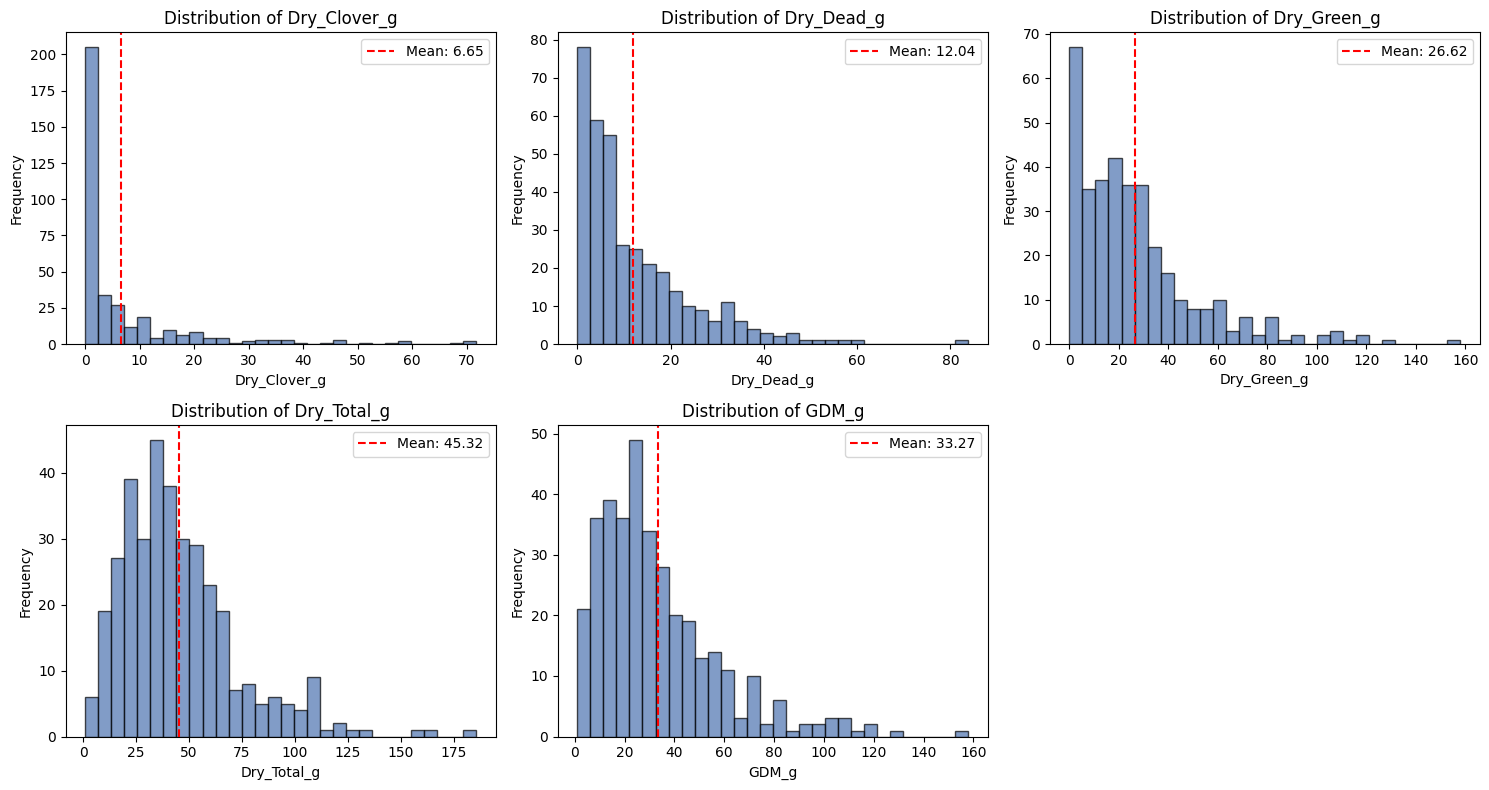

✓ Saved distribution plots to eda_results\visualizations\target_distributions.png


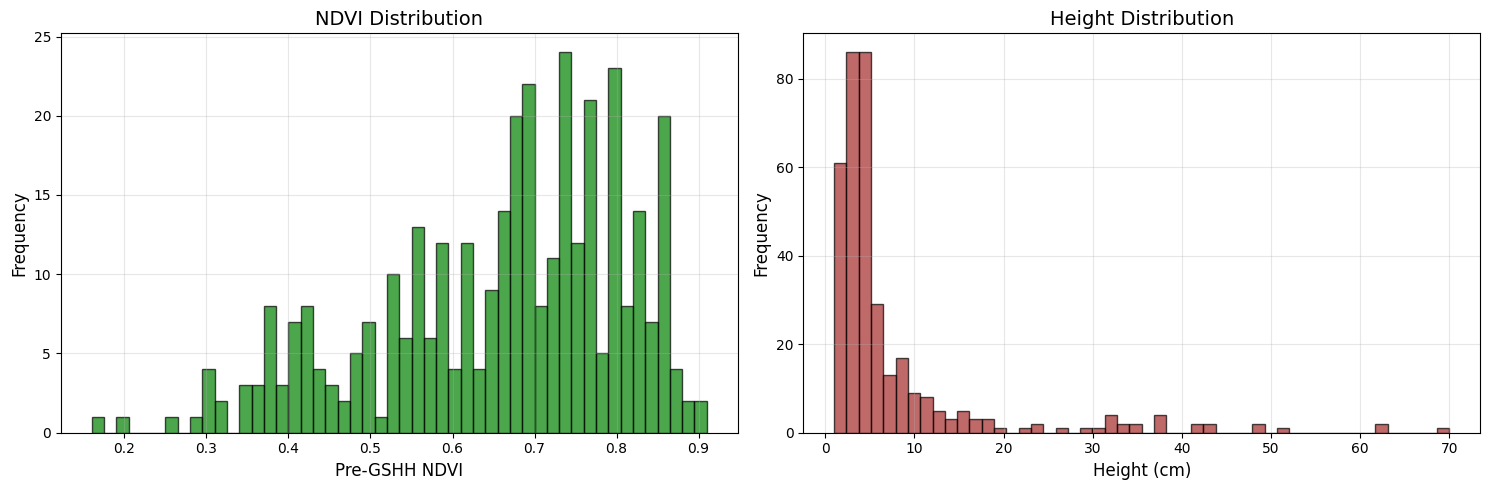

✓ Saved NDVI/Height distributions to eda_results\visualizations\ndvi_height_distributions.png


In [32]:
# Plot target distributions
fig_dist = plot_target_distributions(df_temporal, AVAILABLE_TARGETS)
plt.savefig(OUTPUT_VIZ / 'target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"[OK] Saved distribution plots to {OUTPUT_VIZ / 'target_distributions.png'}")

# Plot NDVI and Height distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_temporal['Pre_GSHH_NDVI'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Pre-GSHH NDVI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('NDVI Distribution')
axes[0].grid(alpha=0.3)

axes[1].hist(df_temporal['Height_Ave_cm'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='brown')
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Height Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_VIZ / 'ndvi_height_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"[OK] Saved NDVI/Height distributions to {OUTPUT_VIZ / 'ndvi_height_distributions.png'}")

### 12.2 Outlier Detection


OUTLIER DETECTION (IQR Method)
Pre_GSHH_NDVI:
  Outliers: 2 (0.56%)
  Lower bound: 0.2450
  Upper bound: 1.0850

Height_Ave_cm:
  Outliers: 43 (12.04%)
  Lower bound: -3.0000
  Upper bound: 13.0000

Dry_Clover_g:
  Outliers: 41 (11.48%)
  Lower bound: -10.8643
  Upper bound: 18.1073

Dry_Dead_g:
  Outliers: 14 (3.92%)
  Lower bound: -18.4567
  Upper bound: 39.2945

Dry_Green_g:
  Outliers: 20 (5.60%)
  Lower bound: -30.6251
  Upper bound: 74.5085

Dry_Total_g:
  Outliers: 16 (4.48%)
  Lower bound: -23.6413
  Upper bound: 106.7928

GDM_g:
  Outliers: 16 (4.48%)
  Lower bound: -25.4483
  Upper bound: 85.1501

✓ Saved outlier summary to eda_results\statistics\outlier_summary.csv


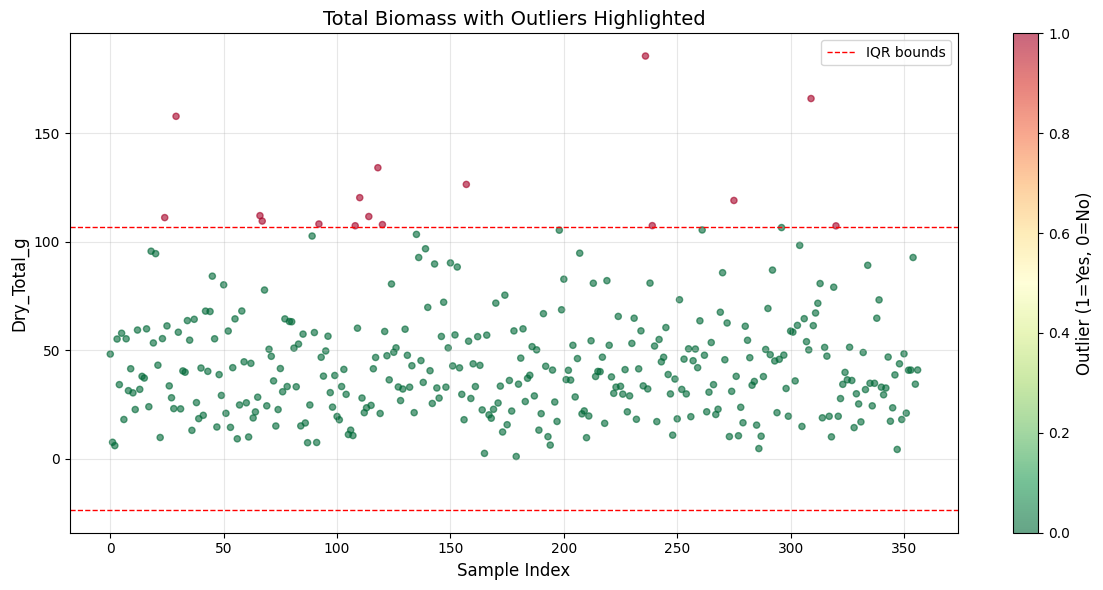

✓ Saved outlier visualization to eda_results\visualizations\outliers_total_biomass.png


In [33]:
# Detect outliers for all numeric features
all_numeric = ['Pre_GSHH_NDVI', 'Height_Ave_cm'] + AVAILABLE_TARGETS

print("\nOUTLIER DETECTION (IQR Method)")
print("="*80)

outlier_summary = []

for col in all_numeric:
    if col in df_temporal.columns:
        outlier_mask = detect_outliers_iqr(df_temporal[col])
        outlier_count = outlier_mask.sum()
        total_count = len(df_temporal[col].dropna())
        outlier_pct = (outlier_count / total_count * 100) if total_count > 0 else 0
        
        # Compute IQR bounds for display
        clean_series = df_temporal[col].dropna()
        if len(clean_series) > 0:
            Q1 = clean_series.quantile(0.25)
            Q3 = clean_series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
        else:
            lower_bound, upper_bound = 0, 0
        
        print(f"{col}:")
        print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")
        print(f"  Lower bound: {lower_bound:.4f}")
        print(f"  Upper bound: {upper_bound:.4f}")
        print()
        
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_pct,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

# Create outlier summary dataframe
outlier_df = pd.DataFrame(outlier_summary)
outlier_df.to_csv(OUTPUT_STATS / 'outlier_summary.csv', index=False)
print(f"[OK] Saved outlier summary to {OUTPUT_STATS / 'outlier_summary.csv'}")

# Visualize outliers
if 'Dry_Total_g' in df_temporal.columns:
    total_outliers_mask = detect_outliers_iqr(df_temporal['Dry_Total_g'])
    
    # Compute bounds for visualization
    clean_total = df_temporal['Dry_Total_g'].dropna()
    Q1_total = clean_total.quantile(0.25)
    Q3_total = clean_total.quantile(0.75)
    IQR_total = Q3_total - Q1_total
    lower_bound_total = Q1_total - 1.5 * IQR_total
    upper_bound_total = Q3_total + 1.5 * IQR_total
    
    fig, ax = plt.subplots(figsize=(12, 6))
    scatter = ax.scatter(range(len(df_temporal)), df_temporal['Dry_Total_g'], 
                        c=total_outliers_mask, cmap='RdYlGn_r', 
                        alpha=0.6, s=20)
    ax.axhline(lower_bound_total, color='red', linestyle='--', linewidth=1, label='IQR bounds')
    ax.axhline(upper_bound_total, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Dry_Total_g')
    ax.set_title('Total Biomass with Outliers Highlighted')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Outlier (1=Yes, 0=No)')
    plt.tight_layout()
    plt.savefig(OUTPUT_VIZ / 'outliers_total_biomass.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"[OK] Saved outlier visualization to {OUTPUT_VIZ / 'outliers_total_biomass.png'}")

---
## 13. Missing Data Analysis

Identify and characterize missing data patterns.

In [34]:
from statistical_utils import analyze_missing_data

print("="*80)
print("MISSING DATA ANALYSIS")
print("="*80)

# Analyze missing data
missing_analysis = analyze_missing_data(df)

print(f"\nTotal missing values: {missing_analysis['total_missing']}")
print(f"\n{missing_analysis['pattern_description']}")

if missing_analysis['total_missing'] > 0:
    print("\nMISSING VALUES BY COLUMN")
    print("="*80)
    display(missing_analysis['missing_by_column'])
    
    print("\nRECOMMENDATIONS")
    print("="*80)
    for rec in missing_analysis['recommendations']:
        print(f"  - {rec}")
    
    # Visualize missing data pattern
    missing_df = missing_analysis['missing_by_column']
    if not missing_df.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(missing_df['column'], missing_df['missing_percentage'], color='coral', alpha=0.7)
        ax.set_xlabel('Missing Percentage (%)')
        ax.set_title('Missing Data by Column')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(OUTPUT_VIZ / 'missing_data_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n[OK] Saved missing data visualization to {OUTPUT_VIZ / 'missing_data_analysis.png'}")
else:
    print("\n[OK] Dataset is complete - no missing values detected!")

MISSING DATA ANALYSIS

Total missing values: 0

No missing values detected - dataset is complete

✓ Dataset is complete - no missing values detected!


---
## 14. Feature Correlation Analysis

Analyze correlations between all features for feature engineering insights.

FEATURE CORRELATION ANALYSIS

PEARSON CORRELATION MATRIX


target_name,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
target_name,,,,,,,
Pre_GSHH_NDVI,1.000000,0.238434,0.224150,-0.122818,0.351054,0.361291,0.466534
Height_Ave_cm,0.238434,1.000000,-0.160138,-0.049721,0.648439,0.497226,0.582722
Dry_Clover_g,0.224150,-0.160138,1.000000,-0.175548,-0.276582,0.104185,0.204213
Dry_Dead_g,-0.122818,-0.049721,-0.175548,1.000000,0.095554,0.453912,0.012028
Dry_Green_g,0.351054,0.648439,-0.276582,0.095554,1.000000,0.830315,0.884257
Dry_Total_g,0.361291,0.497226,0.104185,0.453912,0.830315,1.000000,0.896441
GDM_g,0.466534,0.582722,0.204213,0.012028,0.884257,0.896441,1.000000


✓ Saved to eda_results\statistics\full_correlation_matrix_pearson.csv


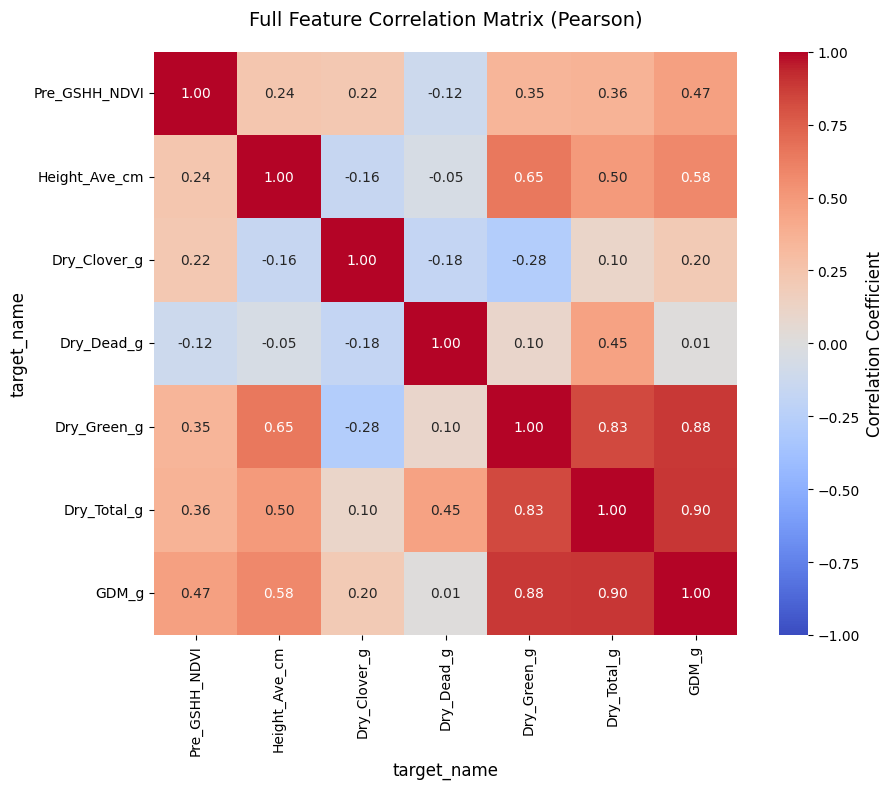

✓ Saved heatmap to eda_results\visualizations\full_correlation_heatmap_pearson.png


In [35]:
from statistical_utils import compute_correlation_matrix
from visualization_utils import plot_correlation_heatmap

print("="*80)
print("FEATURE CORRELATION ANALYSIS")
print("="*80)

# Compute full correlation matrix (Pearson)
numeric_features = ['Pre_GSHH_NDVI', 'Height_Ave_cm'] + AVAILABLE_TARGETS
available_features = [f for f in numeric_features if f in df_temporal.columns]

corr_pearson = compute_correlation_matrix(df_temporal[available_features], method='pearson')

print("\nPEARSON CORRELATION MATRIX")
print("="*80)
display(corr_pearson)

# Save correlation matrix
corr_pearson.to_csv(OUTPUT_STATS / 'full_correlation_matrix_pearson.csv')
print(f"[OK] Saved to {OUTPUT_STATS / 'full_correlation_matrix_pearson.csv'}")

# Visualize Pearson correlations
fig_corr_full = plot_correlation_heatmap(corr_pearson, "Full Feature Correlation Matrix (Pearson)")
plt.savefig(OUTPUT_VIZ / 'full_correlation_heatmap_pearson.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"[OK] Saved heatmap to {OUTPUT_VIZ / 'full_correlation_heatmap_pearson.png'}")

### 14.1 Spearman Correlation (Non-linear Monotonic)

In [36]:
# Compute Spearman correlation
corr_spearman = compute_correlation_matrix(df_temporal[available_features], method='spearman')

print("\nSPEARMAN CORRELATION MATRIX")
print("="*80)
display(corr_spearman)

# Save Spearman correlation matrix
corr_spearman.to_csv(OUTPUT_STATS / 'full_correlation_matrix_spearman.csv')
print(f"[OK] Saved to {OUTPUT_STATS / 'full_correlation_matrix_spearman.csv'}")


SPEARMAN CORRELATION MATRIX


target_name,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
target_name,,,,,,,
Pre_GSHH_NDVI,1.000000,0.399117,0.139328,-0.122681,0.449198,0.424391,0.592137
Height_Ave_cm,0.399117,1.000000,-0.453655,0.210934,0.801956,0.730301,0.687706
Dry_Clover_g,0.139328,-0.453655,1.000000,-0.209235,-0.458614,-0.118806,-0.001720
Dry_Dead_g,-0.122681,0.210934,-0.209235,1.000000,0.116491,0.388622,-0.046134
Dry_Green_g,0.449198,0.801956,-0.458614,0.116491,1.000000,0.726970,0.774130
Dry_Total_g,0.424391,0.730301,-0.118806,0.388622,0.726970,1.000000,0.857807
GDM_g,0.592137,0.687706,-0.001720,-0.046134,0.774130,0.857807,1.000000


✓ Saved to eda_results\statistics\full_correlation_matrix_spearman.csv


### 14.2 High Correlation Pairs

In [37]:
# Identify highly correlated pairs
high_corr = []
for i in range(len(corr_pearson.columns)):
    for j in range(i+1, len(corr_pearson.columns)):
        corr_val = corr_pearson.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr.append({
                'Feature_1': corr_pearson.columns[i],
                'Feature_2': corr_pearson.columns[j],
                'Correlation': corr_val
            })

print("\nHIGHLY CORRELATED PAIRS (|r| > 0.8)")
print("="*80)
if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
    display(high_corr_df)
else:
    print("  No highly correlated pairs found")

# Identify low correlation with targets
print("\nLOW CORRELATION WITH TARGETS (|r| < 0.2)")
print("="*80)
low_corr_features = []
for target in AVAILABLE_TARGETS:
    if target in corr_pearson.columns:
        for feature in ['Pre_GSHH_NDVI', 'Height_Ave_cm']:
            if feature in corr_pearson.index:
                corr_val = corr_pearson.loc[feature, target]
                if abs(corr_val) < 0.2:
                    print(f"  {feature} ↔ {target}: r = {corr_val:.4f} (weak)")
                    low_corr_features.append((feature, target, corr_val))


HIGHLY CORRELATED PAIRS (|r| > 0.8)


,Feature_1,Feature_2,Correlation
2,Dry_Total_g,GDM_g,0.896441
1,Dry_Green_g,GDM_g,0.884257
0,Dry_Green_g,Dry_Total_g,0.830315



LOW CORRELATION WITH TARGETS (|r| < 0.2)
  Height_Ave_cm ↔ Dry_Clover_g: r = -0.1601 (weak)
  Pre_GSHH_NDVI ↔ Dry_Dead_g: r = -0.1228 (weak)
  Height_Ave_cm ↔ Dry_Dead_g: r = -0.0497 (weak)


---
## 15. Comprehensive Rule Summary Report

Consolidate all discovered logical rules for LTN implementation.

In [38]:
print("="*80)
print("COMPREHENSIVE RULE SUMMARY REPORT")
print("="*80)

print(f"\nTotal rules discovered: {len(all_rules)}")

# Categorize rules by type
rule_types = {}
for rule in all_rules:
    rule_type = rule.get('rule_type', 'unknown')
    if rule_type not in rule_types:
        rule_types[rule_type] = []
    rule_types[rule_type].append(rule)

print("\nRULE BREAKDOWN BY TYPE")
print("="*80)
for rule_type, rules in sorted(rule_types.items()):
    print(f"  {rule_type}: {len(rules)} rules")

COMPREHENSIVE RULE SUMMARY REPORT

Total rules discovered: 16

RULE BREAKDOWN BY TYPE
  geographic: 4 rules
  mathematical: 6 rules
  species: 4 rules
  temporal: 2 rules


### 15.1 Detailed Rule Listings

In [39]:
# Display rules by category
for rule_type, rules in sorted(rule_types.items()):
    print(f"\n{'='*80}")
    print(f"{rule_type.upper()} RULES ({len(rules)})")
    print(f"{'='*80}")
    
    for i, rule in enumerate(rules, 1):
        print(f"\n{i}. {rule.get('description', 'No description')}")
        
        # Display pseudo-logic if available
        if 'pseudo_logic' in rule:
            print(f"   Logic: {rule['pseudo_logic']}")
        
        # Display validation metrics
        if 'validation_metrics' in rule:
            metrics = rule['validation_metrics']
            print(f"   Validation:")
            for key, value in metrics.items():
                if isinstance(value, float):
                    print(f"     - {key}: {value:.4f}")
                else:
                    print(f"     - {key}: {value}")
        
        # Display LTN encoding suggestion
        if 'ltn_encoding' in rule:
            print(f"   LTN Encoding: {rule['ltn_encoding']}")
        
        # Display priority if available
        if 'priority' in rule:
            print(f"   Priority: {rule['priority']}")


GEOGRAPHIC RULES (4)

1. State NSW has NDVI in range [0.34, 0.89]
   Logic: FORALL x: State(x) = 'NSW' → 0.340 ≤ NDVI(x) ≤ 0.890
   LTN Encoding: soft_constraint
   Priority: 3

2. State Tas has NDVI in range [0.19, 0.91]
   Logic: FORALL x: State(x) = 'Tas' → 0.190 ≤ NDVI(x) ≤ 0.910
   LTN Encoding: soft_constraint
   Priority: 3

3. State Vic has NDVI in range [0.30, 0.87]
   Logic: FORALL x: State(x) = 'Vic' → 0.300 ≤ NDVI(x) ≤ 0.870
   LTN Encoding: soft_constraint
   Priority: 3

4. State WA has NDVI in range [0.16, 0.81]
   Logic: FORALL x: State(x) = 'WA' → 0.160 ≤ NDVI(x) ≤ 0.810
   LTN Encoding: soft_constraint
   Priority: 3

MATHEMATICAL RULES (6)

1. Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g
   Logic: FORALL x: Dry_Total_g(x) ≈ Dry_Clover_g(x) + Dry_Dead_g(x) + Dry_Green_g(x)
   LTN Encoding: soft_constraint
   Priority: 1

2. GDM_g = 0.799 × Dry_Total_g + -2.925
   Logic: FORALL x: GDM_g(x) ≈ 0.799 * Dry_Total_g(x) + -2.925
   LTN Encoding: soft_constraint
   

### 15.2 Priority Ranking

In [40]:
# Rank rules by strength (using R² or other confidence metrics)
rules_with_confidence = []

for rule in all_rules:
    confidence = 0.0
    
    # Extract confidence from validation metrics
    if 'validation_metrics' in rule:
        metrics = rule['validation_metrics']
        if 'r_squared' in metrics:
            confidence = metrics['r_squared']
        elif 'violation_rate' in metrics:
            confidence = 1.0 - metrics['violation_rate']
        elif 'p_value' in metrics:
            # Convert p-value to confidence (inverse log scale)
            p_val = metrics['p_value']
            if p_val > 0:
                confidence = min(1.0, -np.log10(p_val) / 10.0)
    
    rules_with_confidence.append({
        'rule': rule,
        'confidence': confidence
    })

# Sort by confidence
rules_with_confidence.sort(key=lambda x: x['confidence'], reverse=True)

print("\nTOP 10 RULES BY CONFIDENCE/STRENGTH")
print("="*80)

for i, item in enumerate(rules_with_confidence[:10], 1):
    rule = item['rule']
    confidence = item['confidence']
    print(f"\n{i}. [{rule.get('rule_type', 'unknown')}] {rule.get('description', 'No description')}")
    print(f"   Confidence: {confidence:.4f}")
    if 'pseudo_logic' in rule:
        print(f"   Logic: {rule['pseudo_logic']}")


TOP 10 RULES BY CONFIDENCE/STRENGTH

1. [mathematical] Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g
   Confidence: 0.0000
   Logic: FORALL x: Dry_Total_g(x) ≈ Dry_Clover_g(x) + Dry_Dead_g(x) + Dry_Green_g(x)

2. [mathematical] GDM_g = 0.799 × Dry_Total_g + -2.925
   Confidence: 0.0000
   Logic: FORALL x: GDM_g(x) ≈ 0.799 * Dry_Total_g(x) + -2.925

3. [mathematical] GDM_g = 0.868 × Dry_Green_g + 10.163
   Confidence: 0.0000
   Logic: FORALL x: GDM_g(x) ≈ 0.868 * Dry_Green_g(x) + 10.163

4. [mathematical] Dry_Total_g = 0.915 × Dry_Green_g + 20.963
   Confidence: 0.0000
   Logic: FORALL x: Dry_Total_g(x) ≈ 0.915 * Dry_Green_g(x) + 20.963

5. [mathematical] GDM strongly correlates with green biomass (R²=0.782)
   Confidence: 0.0000
   Logic: FORALL x: Dry_Green_g(x) ≈ 0.901 * GDM_g(x) + -3.348

6. [mathematical] GDM correlates with total biomass (R²=0.804)
   Confidence: 0.0000
   Logic: FORALL x: Dry_Total_g(x) ≈ 1.006 * GDM_g(x) + 11.843

7. [species] Species 'SubcloverLosa' ha

### 15.3 Hard vs Soft Constraint Classification

In [41]:
# Classify rules as hard vs soft constraints
hard_constraints = []
soft_constraints = []

for rule in all_rules:
    # Hard constraint: very low violation rate or mathematically exact
    is_hard = False
    
    if 'validation_metrics' in rule:
        metrics = rule['validation_metrics']
        
        # Check violation rate
        if 'violation_rate' in metrics and metrics['violation_rate'] < 0.05:
            is_hard = True
        
        # Check R² for very strong relationships
        if 'r_squared' in metrics and metrics['r_squared'] > 0.95:
            is_hard = True
    
    # Mathematical rules are typically hard constraints
    if rule.get('rule_type') == 'mathematical':
        is_hard = True
    
    if is_hard:
        hard_constraints.append(rule)
    else:
        soft_constraints.append(rule)

print("\nCONSTRAINT CLASSIFICATION")
print("="*80)
print(f"Hard constraints (violation rate < 5% or R² > 0.95): {len(hard_constraints)} rules")
print(f"Soft constraints (more flexible, domain patterns): {len(soft_constraints)} rules")

print("\nHARD CONSTRAINTS (Strongly Enforced):")
for rule in hard_constraints:
    print(f"  - {rule.get('description', 'No description')}")

print("\nSOFT CONSTRAINTS (Weakly Enforced - LTN Loss Penalties):")
for rule in soft_constraints[:10]:  # Show first 10
    print(f"  - {rule.get('description', 'No description')}")
if len(soft_constraints) > 10:
    print(f"  ... and {len(soft_constraints) - 10} more")


CONSTRAINT CLASSIFICATION
Hard constraints (violation rate < 5% or R² > 0.95): 6 rules
Soft constraints (more flexible, domain patterns): 10 rules

HARD CONSTRAINTS (Strongly Enforced):
  - Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g
  - GDM_g = 0.799 × Dry_Total_g + -2.925
  - GDM_g = 0.868 × Dry_Green_g + 10.163
  - Dry_Total_g = 0.915 × Dry_Green_g + 20.963
  - GDM strongly correlates with green biomass (R²=0.782)
  - GDM correlates with total biomass (R²=0.804)

SOFT CONSTRAINTS (Weakly Enforced - LTN Loss Penalties):
  - Species 'SubcloverLosa' has high clover proportion (mean=1.00)
  - Species 'Clover' has high clover proportion (mean=0.70)
  - Species 'WhiteClover' has high clover proportion (mean=0.32)
  - Species 'Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass' has high clover proportion (mean=0.19)
  - Dead biomass proportion peaks in Winter
  - Green biomass proportion peaks in Summer
  - State NSW has NDVI in range [0.34, 0.89]
  - State Tas has NDVI in range [0

---
## 16. Export and Persistence of Analysis Results

Export all analysis results in multiple formats for downstream use.

In [42]:
import importlib
import export_manager
importlib.reload(export_manager)

from export_manager import (
    export_rules_json,
    export_rules_markdown,
    export_dataframe_csv,
    generate_html_report
)

print("="*80)
print("EXPORTING ANALYSIS RESULTS")
print("="*80)

EXPORTING ANALYSIS RESULTS


### 16.1 Export Discovered Rules

In [43]:
# Export rules in JSON format
json_path = export_rules_json(all_rules, OUTPUT_RULES / 'discovered_rules.json')
print(f"[OK] Exported rules to JSON: {json_path}")

# Export rules in Markdown format
md_path = export_rules_markdown(all_rules, OUTPUT_RULES / 'discovered_rules.md')
print(f"[OK] Exported rules to Markdown: {md_path}")

✓ Exported 16 rules to eda_results\rules\discovered_rules.json
✓ Exported rules to JSON: None
✓ Exported 16 rules to eda_results\rules\discovered_rules.md
✓ Exported rules to Markdown: None


### 16.2 Export Statistical Results

In [44]:
# Export correlation matrices (already saved above, confirming paths)
print(f"\n[OK] Correlation matrices saved:")
print(f"  - {OUTPUT_STATS / 'target_correlations.csv'}")
print(f"  - {OUTPUT_STATS / 'full_correlation_matrix_pearson.csv'}")
print(f"  - {OUTPUT_STATS / 'full_correlation_matrix_spearman.csv'}")

# Export other statistics (already saved above, confirming paths)
print(f"\n[OK] Statistical summaries saved:")
print(f"  - {OUTPUT_STATS / 'descriptive_statistics.csv'}")
print(f"  - {OUTPUT_STATS / 'species_statistics.csv'}")
print(f"  - {OUTPUT_STATS / 'geographic_statistics.csv'}")
print(f"  - {OUTPUT_STATS / 'outlier_summary.csv'}")


✓ Correlation matrices saved:
  - eda_results\statistics\target_correlations.csv
  - eda_results\statistics\full_correlation_matrix_pearson.csv
  - eda_results\statistics\full_correlation_matrix_spearman.csv

✓ Statistical summaries saved:
  - eda_results\statistics\descriptive_statistics.csv
  - eda_results\statistics\species_statistics.csv
  - eda_results\statistics\geographic_statistics.csv
  - eda_results\statistics\outlier_summary.csv


### 16.3 Generate HTML Report

In [45]:
# Create summary statistics for HTML report
summary_stats = {
    'Total Samples': len(df_wide),
    'Total Rules Discovered': len(all_rules),
    'Hard Constraints': len(hard_constraints),
    'Soft Constraints': len(soft_constraints),
    'Unique Species': df['Species'].nunique(),
    'Unique States': df['State'].nunique(),
    'Date Range': f"{df['Sampling_Date'].min()} to {df['Sampling_Date'].max()}",
    'Target Metrics': len(AVAILABLE_TARGETS)
}

# Generate HTML report
html_path = generate_html_report(all_rules, OUTPUT_BASE / 'analysis_report.html', summary_stats)
print(f"\n[OK] Generated HTML report: {html_path}")

✓ Generated HTML report at eda_results\analysis_report.html

✓ Generated HTML report: eda_results\analysis_report.html


### 16.4 Export Summary

In [46]:
print("\n" + "="*80)
print("EXPORT SUMMARY")
print("="*80)

print(f"\nAll results have been exported to: {OUTPUT_BASE}/")
print(f"\nDirectory structure:")
print(f"  [DIR] {OUTPUT_RULES.name}/")
print(f"     - discovered_rules.json")
print(f"     - discovered_rules.md")
print(f"  [DIR] {OUTPUT_VIZ.name}/")
print(f"     - Multiple visualization PNG files (high resolution, 300 dpi)")
print(f"  [DIR] {OUTPUT_STATS.name}/")
print(f"     - descriptive_statistics.csv")
print(f"     - species_statistics.csv")
print(f"     - geographic_statistics.csv")
print(f"     - correlation matrices (Pearson & Spearman)")
print(f"     - outlier_summary.csv")
print(f"  [FILE] analysis_report.html")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE!")
print(f"{'='*80}")
print(f"\n[OK] {len(all_rules)} logical rules discovered for LTN implementation")
print(f"[OK] {len(hard_constraints)} hard constraints identified")
print(f"[OK] {len(soft_constraints)} soft constraints identified")
print(f"\nRule categories:")
for rule_type, count in sorted([(t, len(r)) for t, r in rule_types.items()], key=lambda x: x[1], reverse=True):
    print(f"  - {rule_type}: {count} rules")

print(f"\n Biomass EDA for LTN Rule Discovery completed successfully!")
print(f"\nNext steps:")
print(f"  1. Review discovered rules in {OUTPUT_RULES / 'discovered_rules.md'}")
print(f"  2. Examine visualizations in {OUTPUT_VIZ}/")
print(f"  3. Open HTML report for comprehensive overview: {OUTPUT_BASE / 'analysis_report.html'}")
print(f"  4. Use rules to design LTN soft constraint loss layer")
print(f"  5. Implement baseline models (neural-only, symbolic-only, neuro-symbolic)")


EXPORT SUMMARY

All results have been exported to: eda_results/

Directory structure:
  📁 rules/
     - discovered_rules.json
     - discovered_rules.md
  📁 visualizations/
     - Multiple visualization PNG files (high resolution, 300 dpi)
  📁 statistics/
     - descriptive_statistics.csv
     - species_statistics.csv
     - geographic_statistics.csv
     - correlation matrices (Pearson & Spearman)
     - outlier_summary.csv
  📄 analysis_report.html

ANALYSIS COMPLETE!

✓ 16 logical rules discovered for LTN implementation
✓ 6 hard constraints identified
✓ 10 soft constraints identified

Rule categories:
  - mathematical: 6 rules
  - species: 4 rules
  - geographic: 4 rules
  - temporal: 2 rules

🎉 Biomass EDA for LTN Rule Discovery completed successfully!

Next steps:
  1. Review discovered rules in eda_results\rules\discovered_rules.md
  2. Examine visualizations in eda_results\visualizations/
  3. Open HTML report for comprehensive overview: eda_results\analysis_report.html
  4. Use